# Univariate and Bivariate Analysis of Application (Application Process) Data
- table - application_train.csv
---

__Application info__:
- `NAME_TYPE_SUITE` - Who was accompanying client when he was applying for the loan
- `DAYS_ID_PUBLISH` - How many days before the application did client change the identity document with which he applied for the loan, time only
- `DAYS_EMPLOYED` - How many days before the application the person started current employment, time only relative to the application
- `DAYS_REGISTRATION` - How many days before the application did client change his registration, time only relative to the application
- `DAYS_LAST_PHONE_CHANGE` - How many days before application did client change phone
- `WEEKDAY_APPR_PROCESS_START` On which day of the week did the client apply for the loan
- `HOUR_APPR_PROCESS_START` - Approximately at what hour did the client apply for the loan, rounded
- `FLAG_MOBIL` - Did client provide mobile phone (1=YES, 0=NO)
- `FLAG_EMP_PHONE` - Did client provide work phone (1=YES, 0=NO)
- `FLAG_WORK_PHONE` - Did client provide home phone (1=YES, 0=NO)
- `FLAG_CONT_MOBILE` - Was mobile phone reachable (1=YES, 0=NO)
- `FLAG_PHONE` - Did client provide home phone (1=YES, 0=NO) (Possible duplicate with FLAG_WORK_PHONE)
- `FLAG_EMAIL` - Did client provide email (1=YES, 0=NO)

## 0. Data and libraries

In [1]:
import pandas as pd
import numpy as np

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_PATH = PROJECT_ROOT / 'src'

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from eda_module import (
    plot_quantitative_distribution, plot_categorical_distribution, plot_binary_distribution, 
    plot_binary_vs_binary, plot_categorical_distribution, plot_quantitative_vs_binary,
    plot_categorical_vs_binary
)
from preprocess_module import (
    create_imputed_quantitative_features, bin_quantitative_var
) 

In [2]:
app_df = pd.read_csv(r"..\data\raw\application_train.csv")
print(f"Shape of app_df: {app_df.shape}")
app_df.head(10)

Shape of app_df: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
6,100009,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,...,0,0,0,0,0.0,0.0,0.0,1.0,1.0,2.0
7,100010,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
8,100011,0,Cash loans,F,N,Y,0,112500.0,1019610.0,33826.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
9,100012,0,Revolving loans,M,N,Y,0,135000.0,405000.0,20250.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
application_cols = [
    'TARGET', 'NAME_TYPE_SUITE','DAYS_ID_PUBLISH','DAYS_EMPLOYED','DAYS_REGISTRATION',
    'DAYS_LAST_PHONE_CHANGE','WEEKDAY_APPR_PROCESS_START','HOUR_APPR_PROCESS_START',
    'FLAG_MOBIL','FLAG_EMP_PHONE','FLAG_WORK_PHONE','FLAG_CONT_MOBILE','FLAG_PHONE','FLAG_EMAIL'
]
app_df[application_cols].head(10)

,TARGET,NAME_TYPE_SUITE,DAYS_ID_PUBLISH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_LAST_PHONE_CHANGE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL
0,1,Unaccompanied,-2120,-637,-3648.0,-1134.0,WEDNESDAY,10,1,1,0,1,1,0
1,0,Family,-291,-1188,-1186.0,-828.0,MONDAY,11,1,1,0,1,1,0
2,0,Unaccompanied,-2531,-225,-4260.0,-815.0,MONDAY,9,1,1,1,1,1,0
3,0,Unaccompanied,-2437,-3039,-9833.0,-617.0,WEDNESDAY,17,1,1,0,1,0,0
4,0,Unaccompanied,-3458,-3038,-4311.0,-1106.0,THURSDAY,11,1,1,0,1,0,0
5,0,"Spouse, partner",-477,-1588,-4970.0,-2536.0,WEDNESDAY,16,1,1,1,1,1,0
6,0,Unaccompanied,-619,-3130,-1213.0,-1562.0,SUNDAY,16,1,1,0,1,1,0
7,0,Unaccompanied,-2379,-449,-4597.0,-1070.0,MONDAY,16,1,1,1,1,0,0
8,0,Children,-3514,365243,-7427.0,0.0,WEDNESDAY,14,1,0,0,1,0,0
9,0,Unaccompanied,-3992,-2019,-14437.0,-1673.0,THURSDAY,8,1,1,0,1,0,0


## 1. NAME_TYPE_SUITE
Who was accompanying client when he was applying for the loan

In [4]:
app_df['NAME_TYPE_SUITE'].value_counts()

NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
Other_A               866
Group of people       271
Name: count, dtype: int64

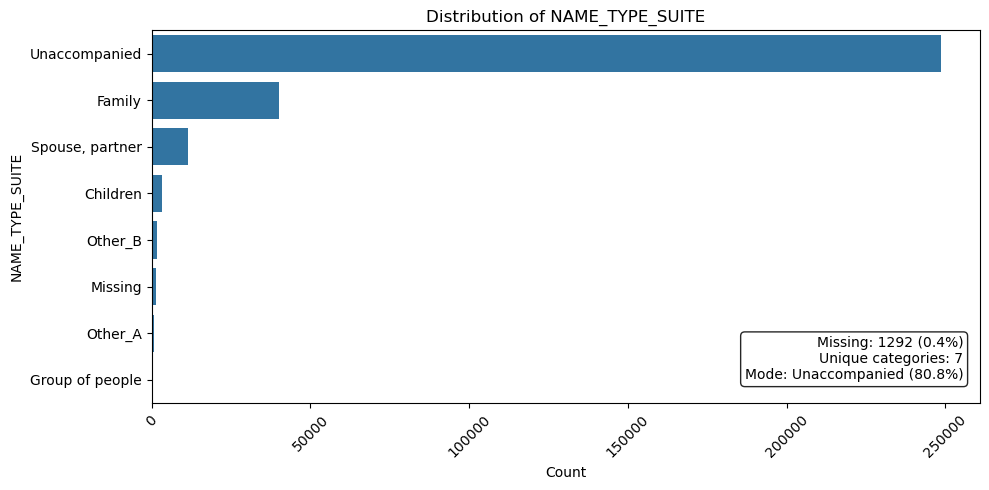

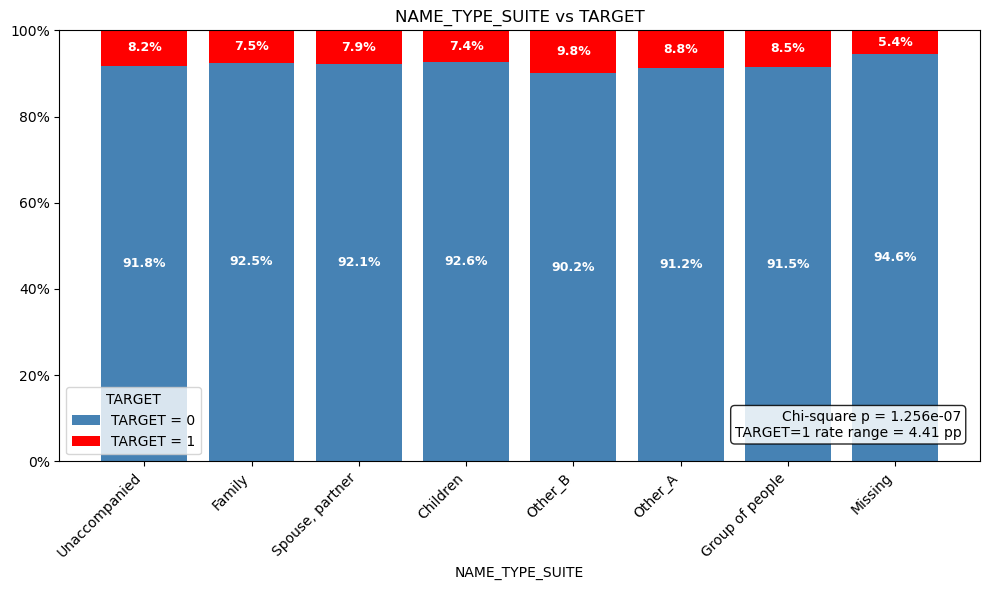

In [5]:
plot_categorical_distribution(df=app_df, cat_var='NAME_TYPE_SUITE')
plot_categorical_vs_binary(df=app_df, cat_var='NAME_TYPE_SUITE', target_var='TARGET')

In [6]:
app_df['NAME_TYPE_SUITE_grouped'] = np.where(
    app_df['NAME_TYPE_SUITE'].isin(['Children', 'Other_B', 'Other_A', 'Group of people']),
    'Other',
    app_df['NAME_TYPE_SUITE']
)
app_df['NAME_TYPE_SUITE_grouped'].value_counts()

NAME_TYPE_SUITE_grouped
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Other                6174
Name: count, dtype: int64

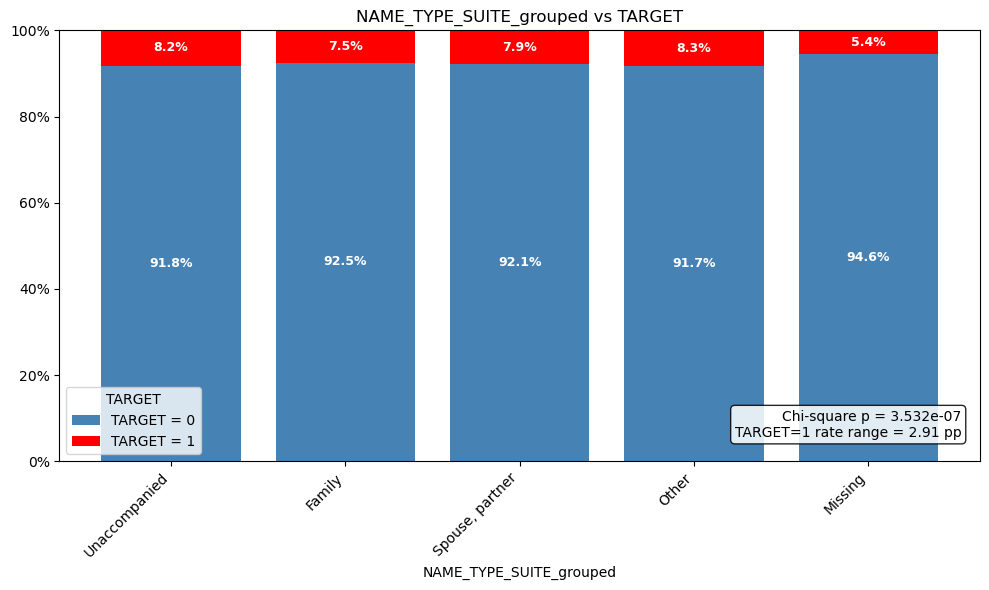

In [7]:
plot_categorical_vs_binary(df=app_df, cat_var='NAME_TYPE_SUITE_grouped', target_var='TARGET')

There are small differences between categories, only `Missing` shows significantly lower number of `TARGET = 1`.
We can add binary variable `NAME_TYPE_SUITE_missing`.

## 2. DAYS_ID_PUBLISH
How many days before the application did the client change the identity document with which he applied for the loan, time only

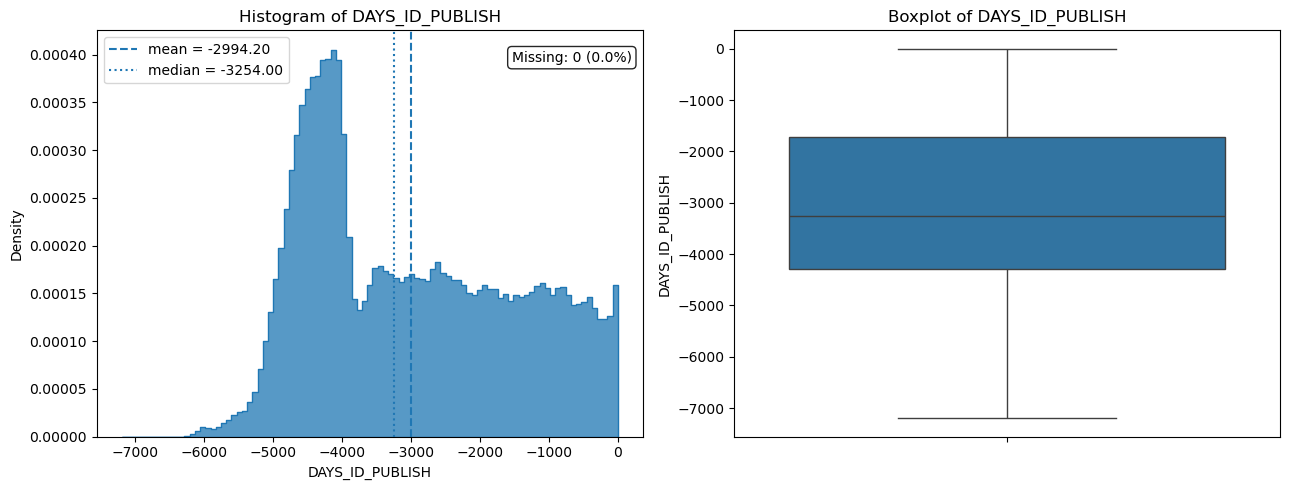

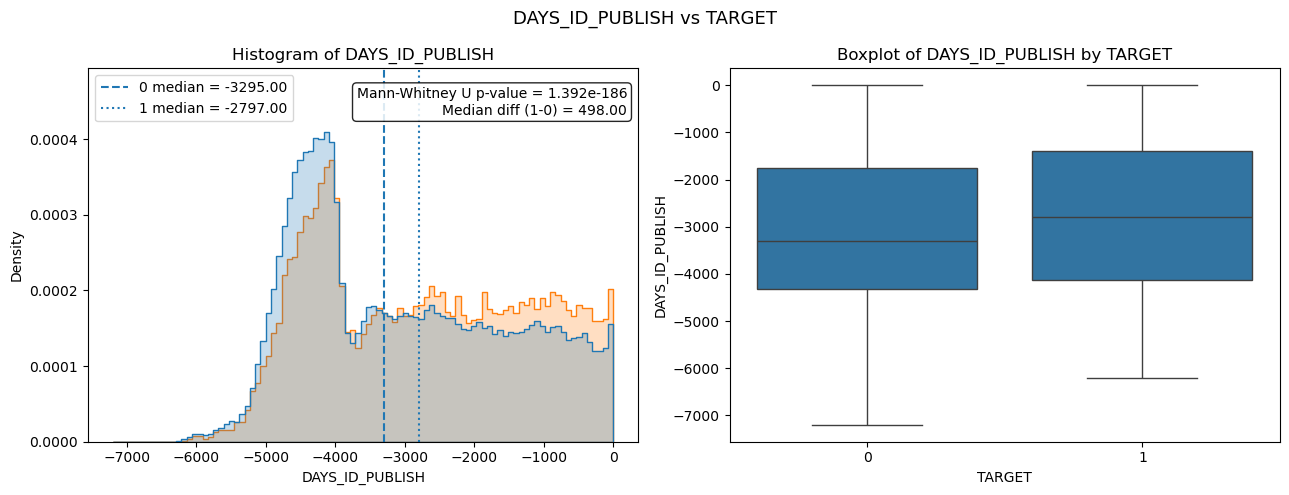

In [8]:
plot_quantitative_distribution(df=app_df, quant_var='DAYS_ID_PUBLISH')
plot_quantitative_vs_binary(df=app_df, quant_var='DAYS_ID_PUBLISH', target_var='TARGET')

Clients who defaulted changed their document with which they applied for a loan signifianlty earlier. <br>
This variable propably hold important information for our modeling.

In [9]:
binned_df, days_id_publish_summary = bin_quantitative_var(
    df = app_df,
    quant_var='DAYS_ID_PUBLISH',
    quantiles_bins=True,
    target_var='TARGET',
    return_binned_quantiles=False,
    return_summary=True,
    return_df=True
)

days_id_publish_summary

,feature,binned_column,binning_type,bin,count,share,n_target_1,n_target_0,target_rate
0,DAYS_ID_PUBLISH,DAYS_ID_PUBLISH_binned_quantiles,quantiles,Q1,61598,0.200312,3731,57867,0.060570
1,DAYS_ID_PUBLISH,DAYS_ID_PUBLISH_binned_quantiles,quantiles,Q2,61414,0.199713,4363,57051,0.071042
2,DAYS_ID_PUBLISH,DAYS_ID_PUBLISH_binned_quantiles,quantiles,Q3,61551,0.200159,4967,56584,0.080697
3,DAYS_ID_PUBLISH,DAYS_ID_PUBLISH_binned_quantiles,quantiles,Q4,61447,0.199820,5618,55829,0.091428
4,DAYS_ID_PUBLISH,DAYS_ID_PUBLISH_binned_quantiles,quantiles,Q5,61501,0.199996,6146,55355,0.099933


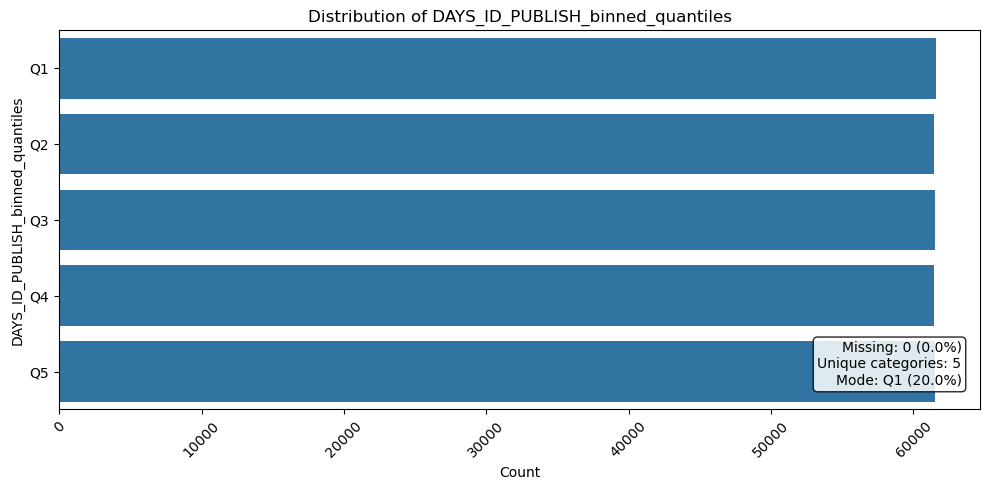

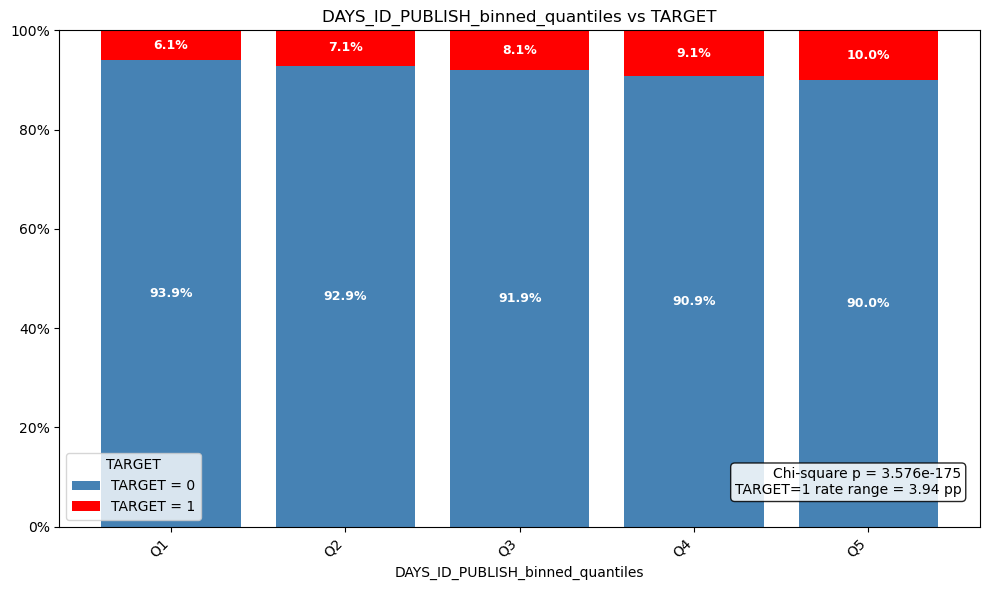

In [10]:
plot_categorical_distribution(df=binned_df, cat_var='DAYS_ID_PUBLISH_binned_quantiles', respect_category_order=True)
plot_categorical_vs_binary(df=binned_df, cat_var='DAYS_ID_PUBLISH_binned_quantiles', target_var='TARGET', respect_category_order=True)

## 3. DAYS_EMPLOYED
How many days before the application the person started current employment,time only relative to the application

In [11]:
app_df['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

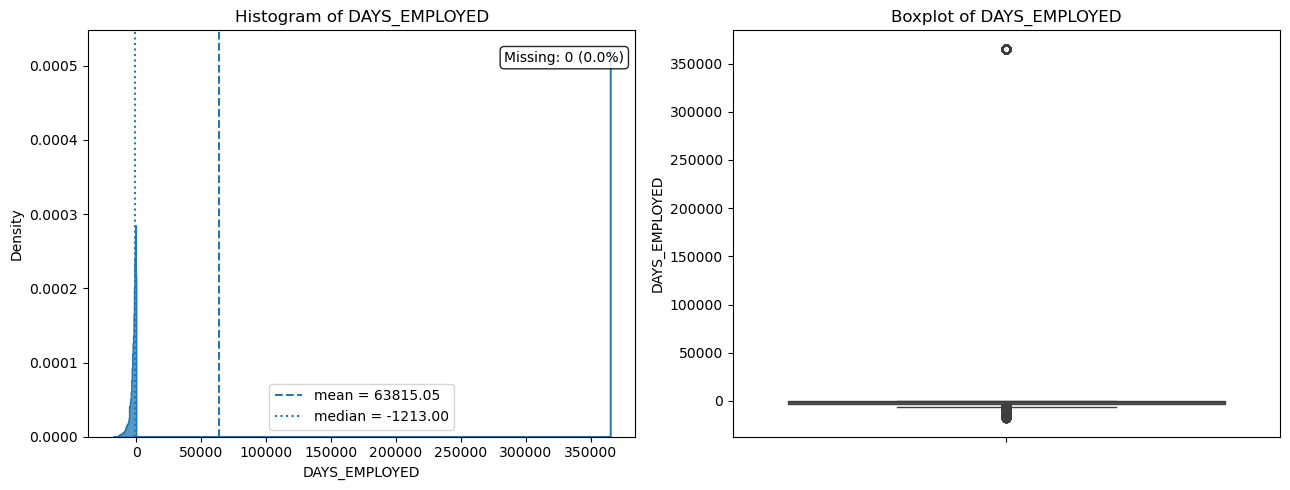

In [12]:
plot_quantitative_distribution(df=app_df, quant_var='DAYS_EMPLOYED')

In [13]:
app_df.loc[app_df['DAYS_EMPLOYED'] == 365243.000000].shape

(55374, 123)

In [14]:
app_df.loc[app_df['DAYS_EMPLOYED'] > 0].shape

(55374, 123)

In [15]:
round(app_df.loc[app_df['DAYS_EMPLOYED'] > 0].shape[0] / len(app_df),4)

0.1801

55374 observations have `DAYS_EMPLOYED` = 365243, which translates into over 1000 years, other than that this variable should have values < 0.

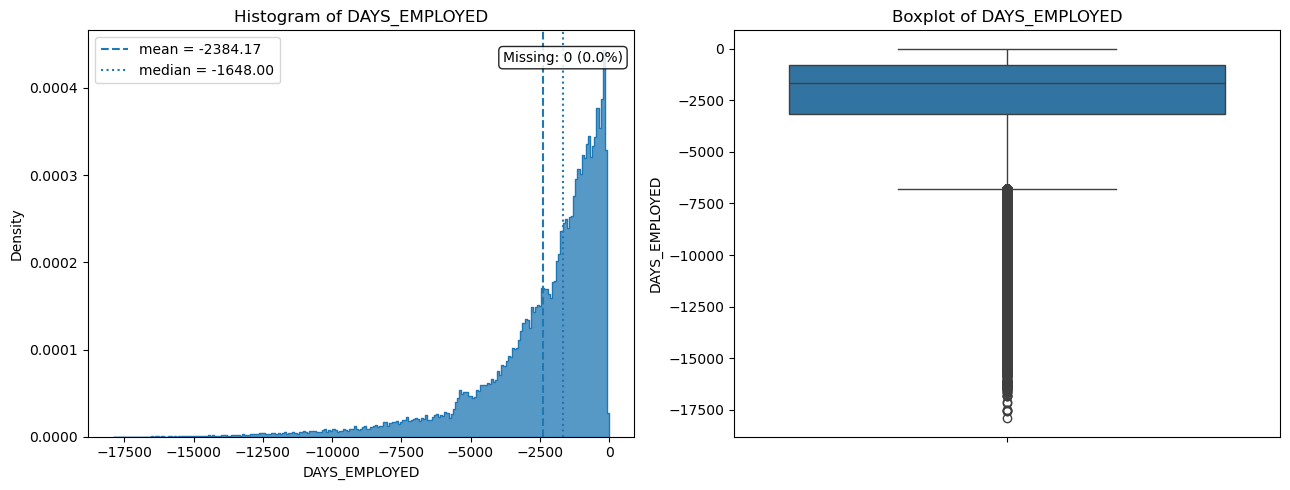

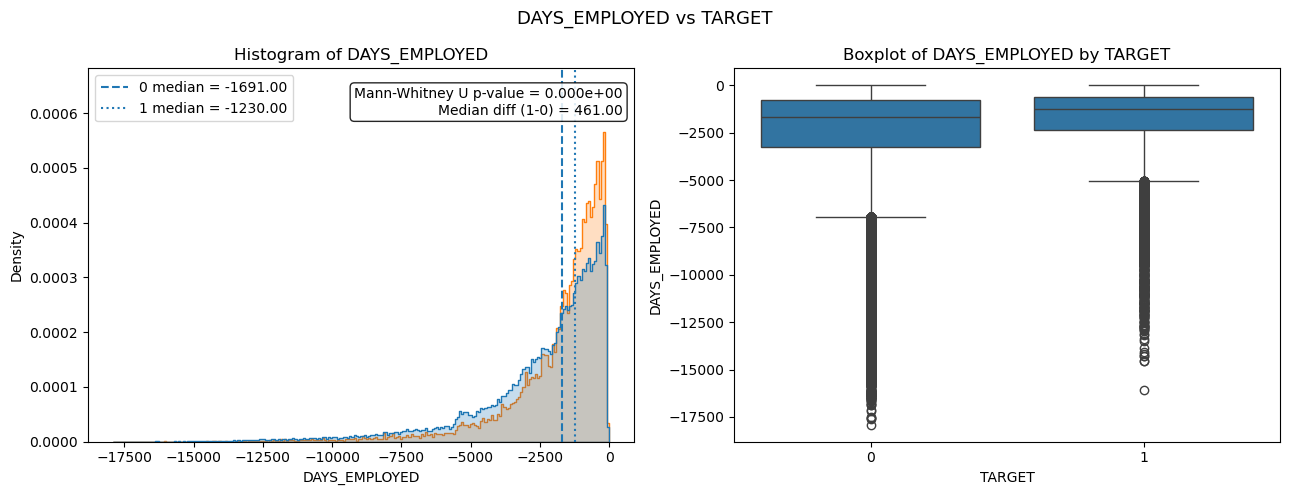

In [16]:
plot_quantitative_distribution(df=app_df.loc[app_df['DAYS_EMPLOYED']< 365243], quant_var='DAYS_EMPLOYED')
plot_quantitative_vs_binary(df=app_df.loc[app_df['DAYS_EMPLOYED']< 365243], quant_var='DAYS_EMPLOYED', target_var='TARGET')

There is statistically significant difference between distributions, `DAYS_EMPLOYED` might me considered as predictor. <br>
We will also check if the invalid values also affect the `TARGET`

In [17]:
app_df['DAYS_EMPLOYED_invalid'] = np.where(
    app_df['DAYS_EMPLOYED'] > 0,
    1,
    0
)
app_df['DAYS_EMPLOYED_invalid'].value_counts()

DAYS_EMPLOYED_invalid
0    252137
1     55374
Name: count, dtype: int64

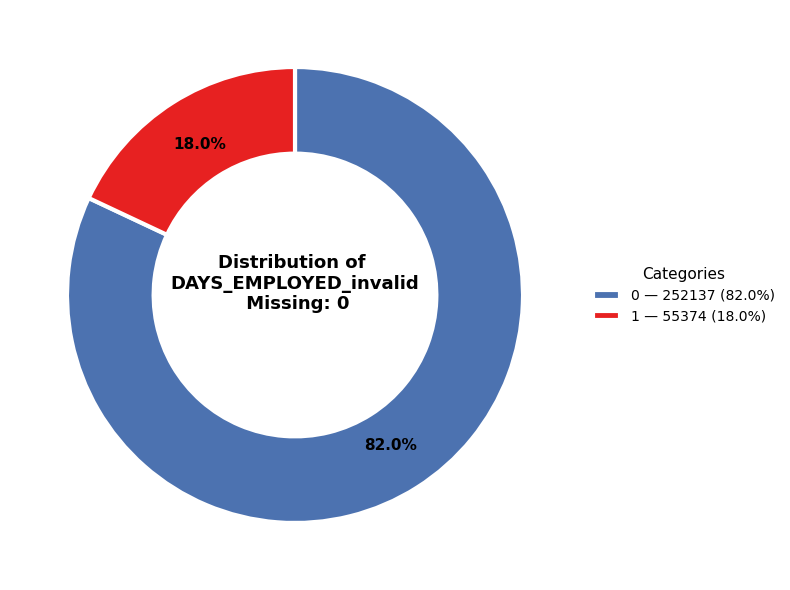

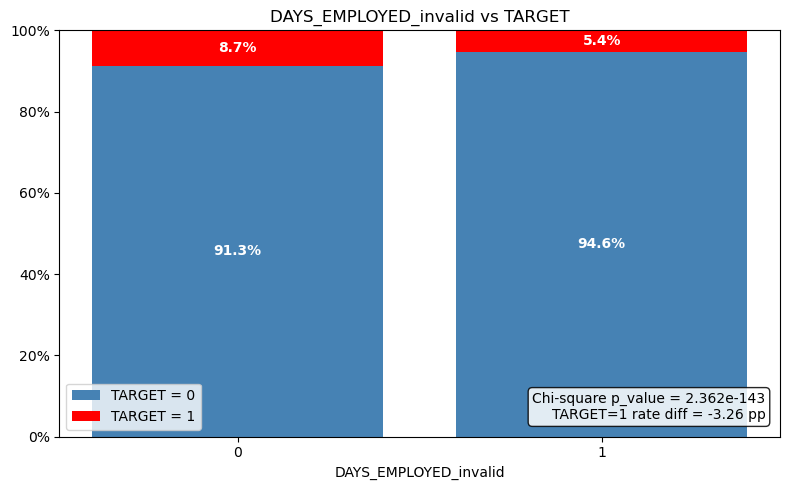

In [18]:
plot_binary_distribution(df=app_df, binary_var='DAYS_EMPLOYED_invalid')
plot_binary_vs_binary(df=app_df, binary_var='DAYS_EMPLOYED_invalid', target_var='TARGET')

There is small, but significant difference in distributions.
The invalid values will be imputed with the median

In [19]:
app_df['DAYS_EMPLOYED_imp_global'] = np.where(
    app_df['DAYS_EMPLOYED'] > 0,
    app_df['DAYS_EMPLOYED'].median(),
    app_df['DAYS_EMPLOYED']
)
app_df['DAYS_EMPLOYED_imp_global'].describe()

count    307511.000000
mean      -2173.274982
std        2164.676336
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -933.000000
max           0.000000
Name: DAYS_EMPLOYED_imp_global, dtype: float64

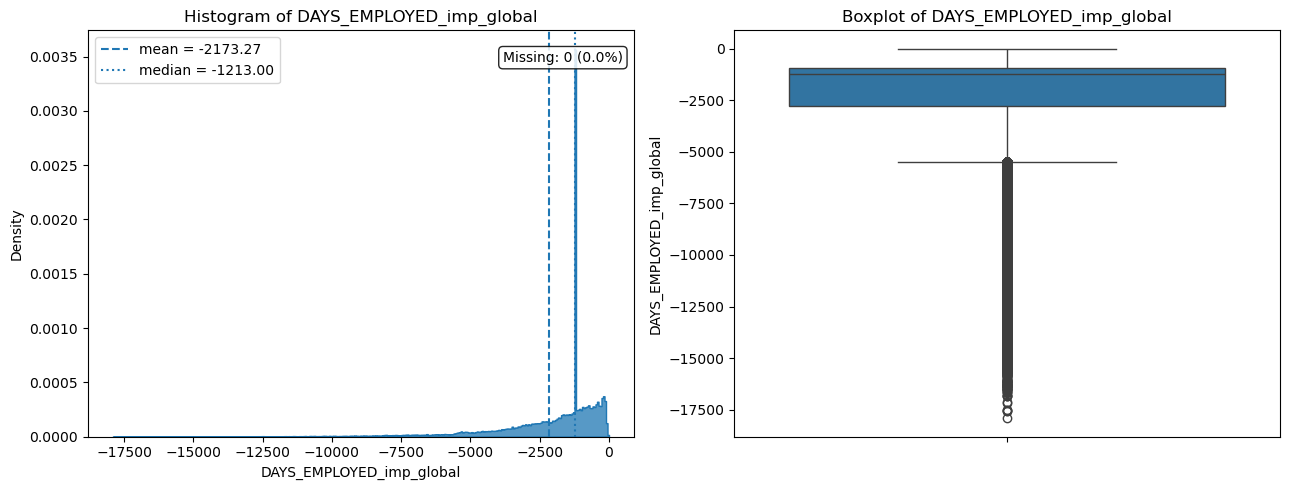

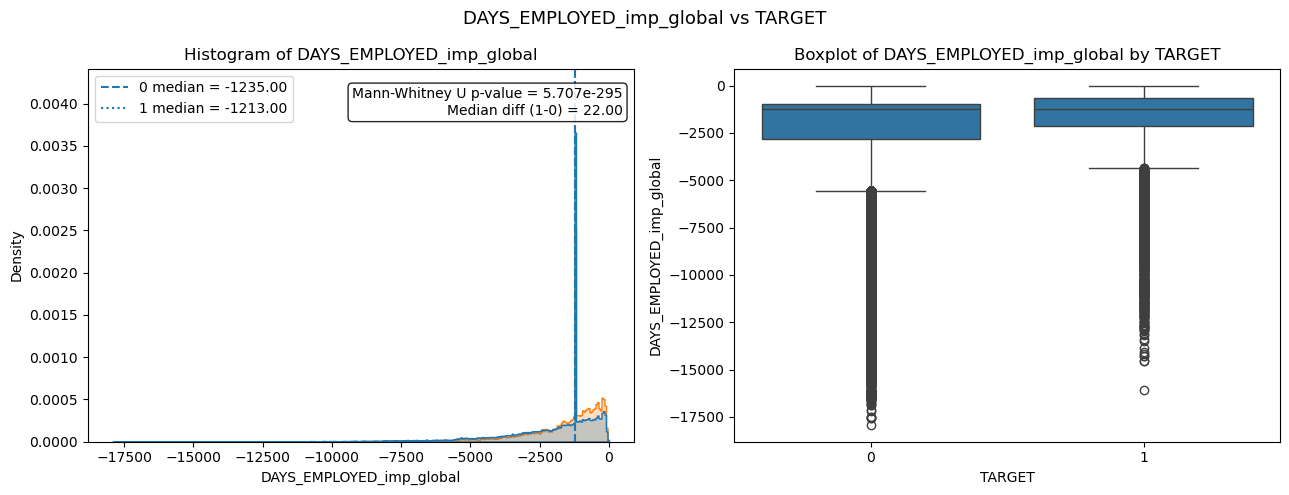

In [20]:
plot_quantitative_distribution(df=app_df, quant_var='DAYS_EMPLOYED_imp_global')
plot_quantitative_vs_binary(df=app_df, quant_var='DAYS_EMPLOYED_imp_global', target_var='TARGET')

Imputing such variable with the global median results in washing up the previous signal by artificially pulling big number of observations to one value.
We will consider:
- imputation with medians for different groups for other variables (`INCOME_TYPE`)
- leaving it with extreme value (`365243`) for tree based models

In [21]:
imputation_specs = {
    "DAYS_EMPLOYED_imp_income": {
        "method": "median",
        "group_levels": [["NAME_INCOME_TYPE"]],
    },
    "DAYS_EMPLOYED_imp_income_gender": {
        "method": "median",
        "group_levels": [["NAME_INCOME_TYPE", "CODE_GENDER"], ["NAME_INCOME_TYPE"]],
    },
    "DAYS_EMPLOYED_imp_occupation": {
        "method": "median",
        "group_levels": [["OCCUPATION_TYPE"]],
    },
    "DAYS_EMPLOYED_imp_occupation_gender": {
        "method": "median",
        "group_levels": [["OCCUPATION_TYPE", "CODE_GENDER"], ["OCCUPATION_TYPE"]],
    },
}

df_imp, summary = create_imputed_quantitative_features(
    df=app_df,
    value_col="DAYS_EMPLOYED",
    specs=imputation_specs,
    invalid_value=365243,
    add_clean_col=False,
    add_invalid_flag=False
)

df_imp.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR', 'NAME_TYPE_SUITE_grouped',
       'DAYS_EMPLOYED_invalid', 'DAYS_EMPLOYED_imp_global',
       'DAYS_EMPLOYED_imp_income', 'DAYS_EMPLOYED_imp_income_gender',
       'DAYS_EMPLOYED_imp_occupation', 'DAYS_EMPLOYED_imp_occupation_gender'],
      dtype='object', length=129)

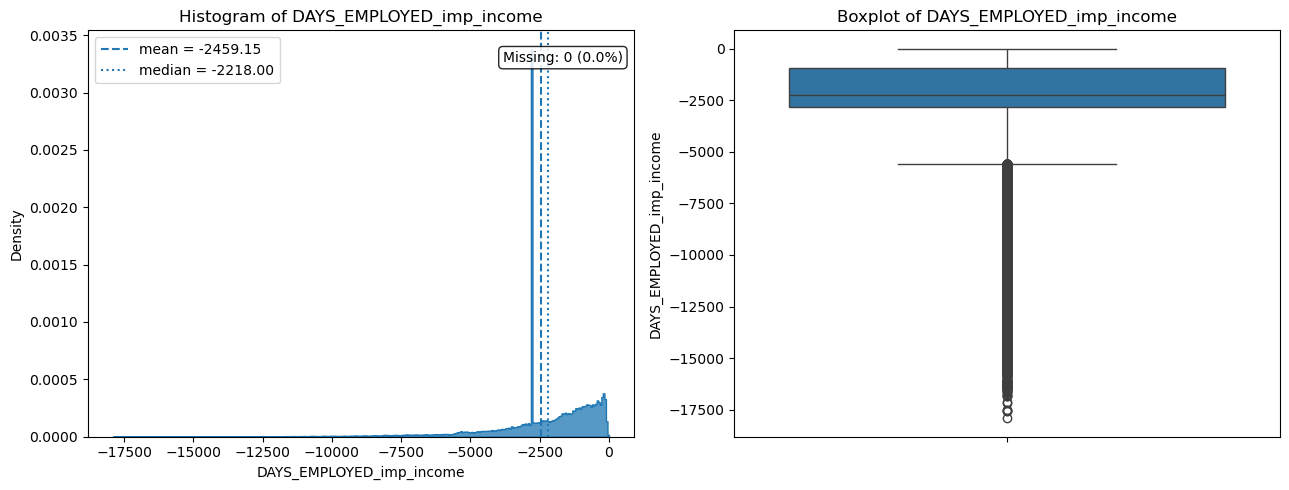

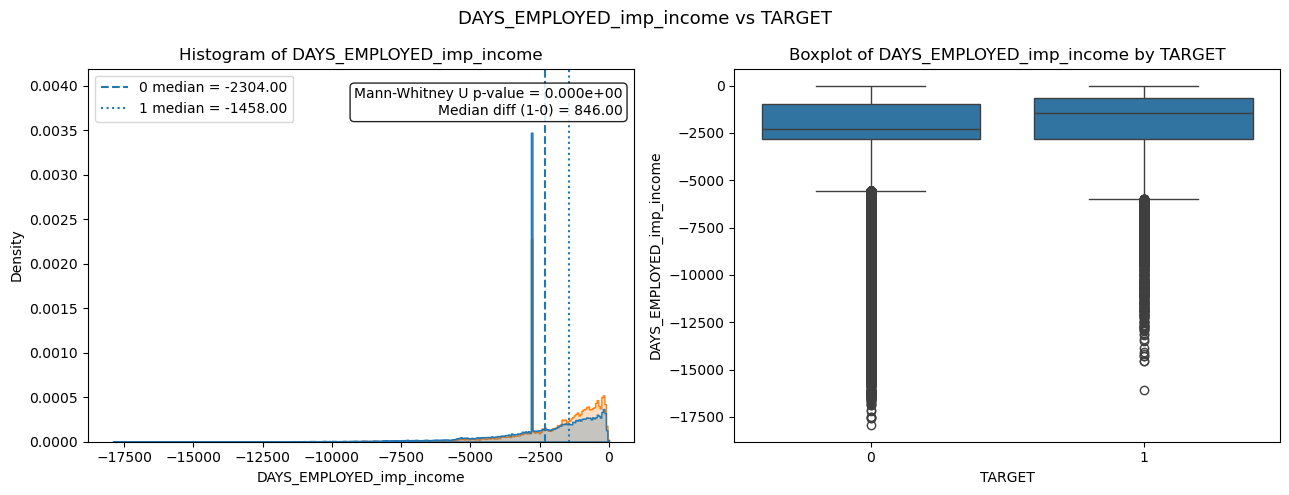

In [22]:
plot_quantitative_distribution(df=df_imp, quant_var='DAYS_EMPLOYED_imp_income')
plot_quantitative_vs_binary(df=df_imp, quant_var='DAYS_EMPLOYED_imp_income', target_var='TARGET')

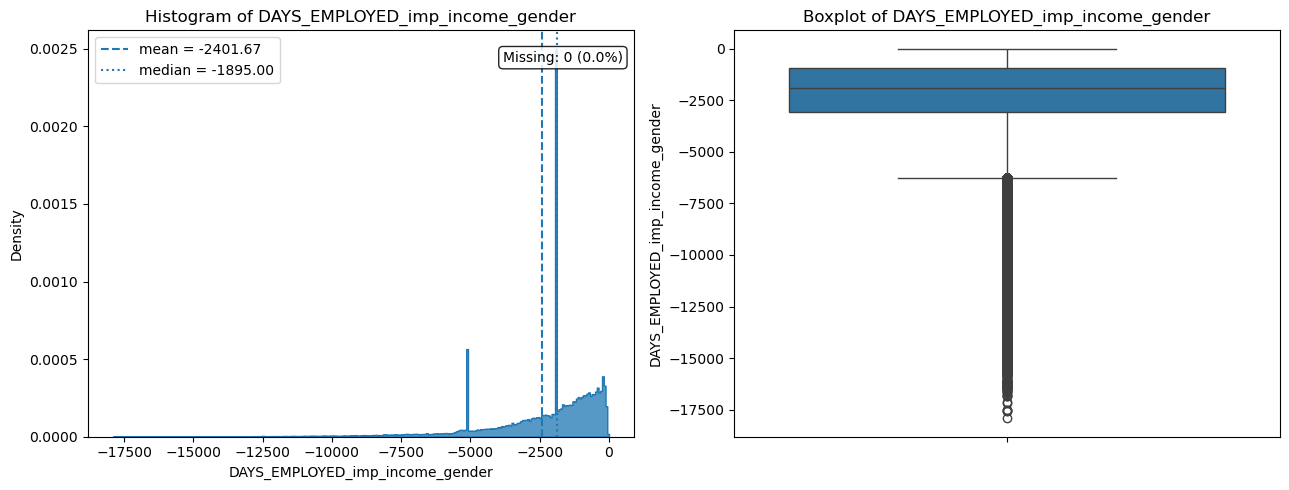

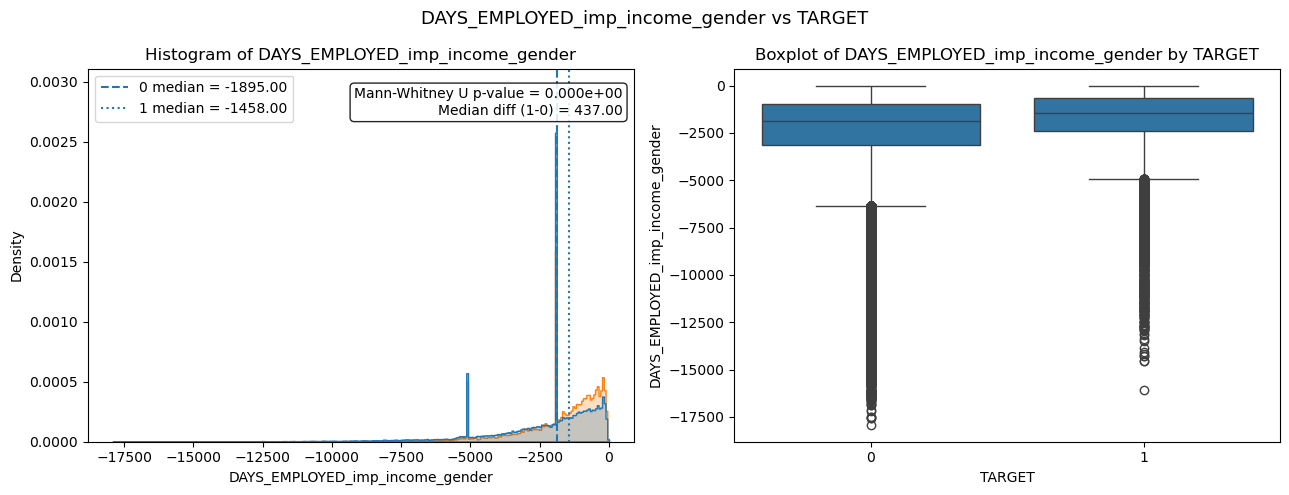

In [23]:
plot_quantitative_distribution(df=df_imp, quant_var='DAYS_EMPLOYED_imp_income_gender')
plot_quantitative_vs_binary(df=df_imp, quant_var='DAYS_EMPLOYED_imp_income_gender', target_var='TARGET')

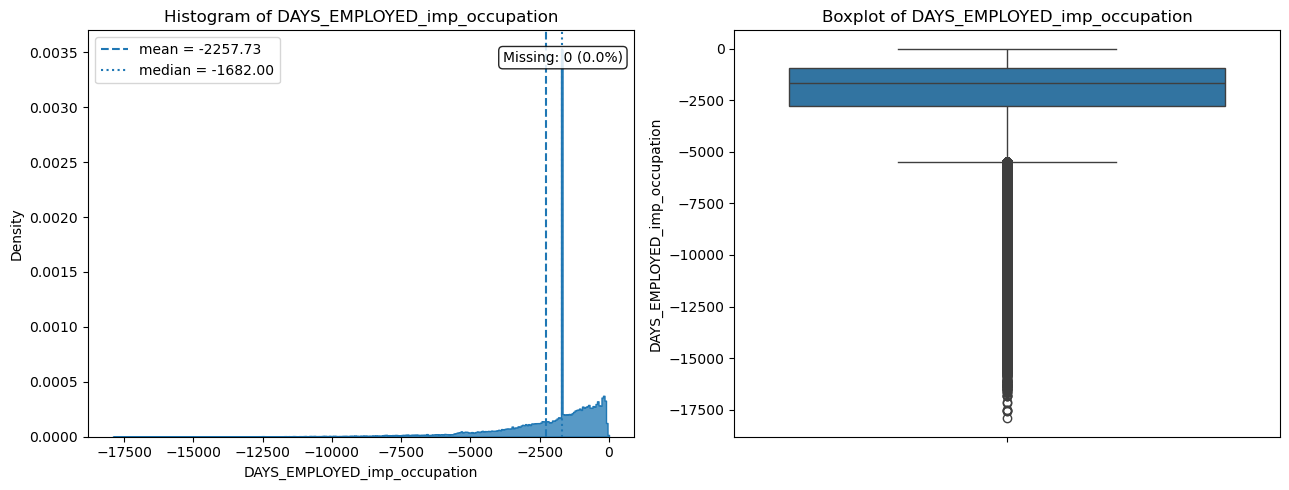

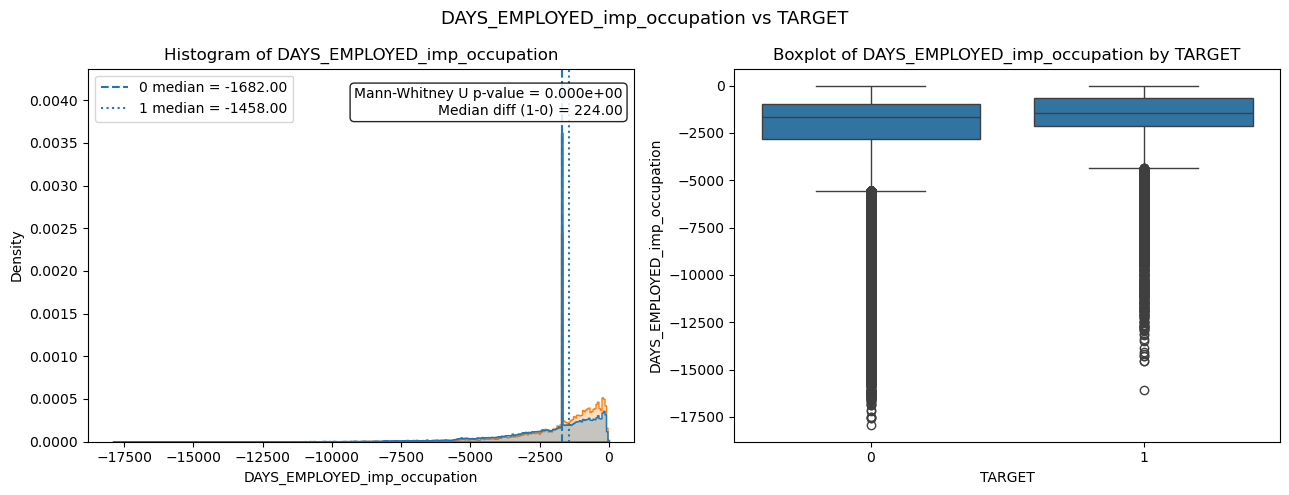

In [24]:
plot_quantitative_distribution(df=df_imp, quant_var='DAYS_EMPLOYED_imp_occupation')
plot_quantitative_vs_binary(df=df_imp, quant_var='DAYS_EMPLOYED_imp_occupation', target_var='TARGET')

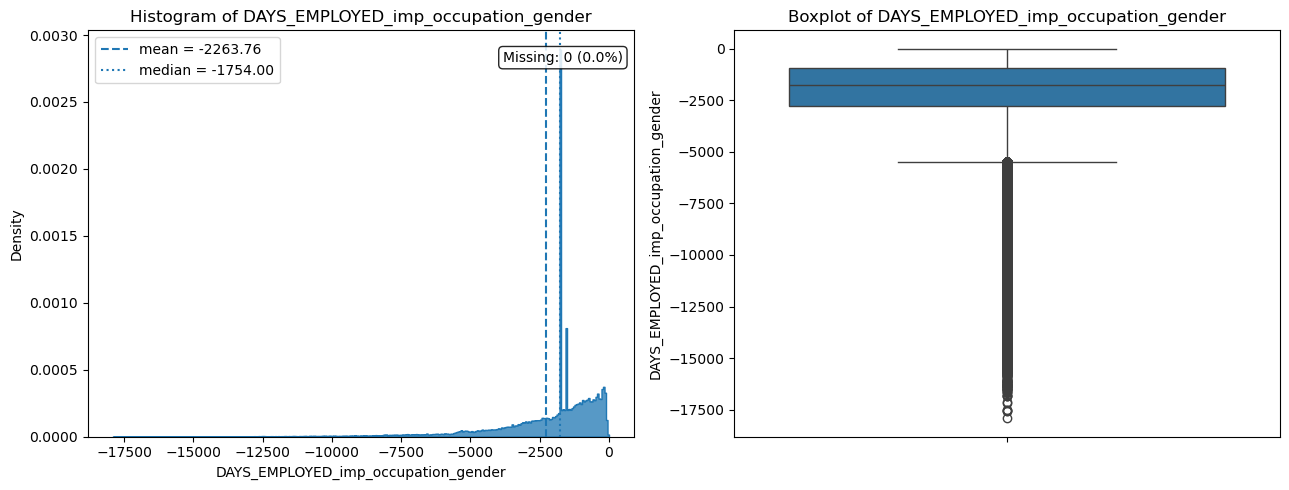

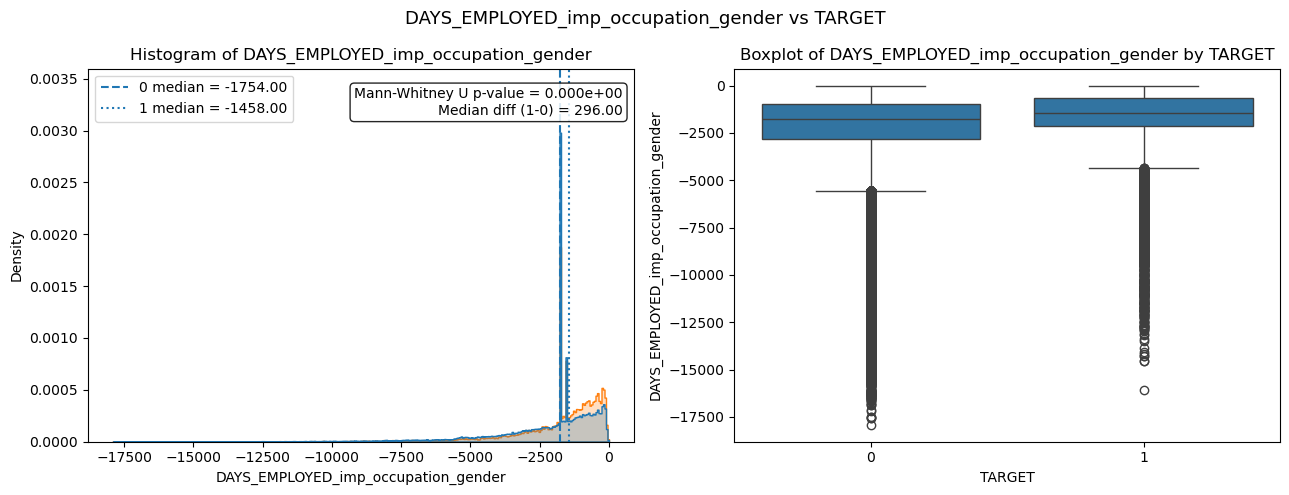

In [25]:
plot_quantitative_distribution(df=df_imp, quant_var='DAYS_EMPLOYED_imp_occupation_gender')
plot_quantitative_vs_binary(df=df_imp, quant_var='DAYS_EMPLOYED_imp_occupation_gender', target_var='TARGET')

The biggest difference in distributions can be observed in `DAYS_EMPLOYED_imp_income` which is `DAYS_EMPLOYED` imputed by medians within `INCOME_TYPE` groups. This might be imputed variable holding the biggest amount of information.

In [26]:
binned_df, days_employed_summary = bin_quantitative_var(
    df = df_imp,
    quant_var='DAYS_EMPLOYED_imp_income',
    quantiles_bins=True,
    target_var='TARGET',
    return_binned_quantiles=False,
    return_summary=True,
    return_df=True
)

days_employed_summary

,feature,binned_column,binning_type,bin,count,share,n_target_1,n_target_0,target_rate
0,DAYS_EMPLOYED_imp_income,DAYS_EMPLOYED_imp_income_binned_quantiles,quantiles,Q1,61516,0.200045,3307,58209,0.053758
1,DAYS_EMPLOYED_imp_income,DAYS_EMPLOYED_imp_income_binned_quantiles,quantiles,Q2,69187,0.224990,3979,65208,0.057511
2,DAYS_EMPLOYED_imp_income,DAYS_EMPLOYED_imp_income_binned_quantiles,quantiles,Q3,53870,0.175181,4361,49509,0.080954
3,DAYS_EMPLOYED_imp_income,DAYS_EMPLOYED_imp_income_binned_quantiles,quantiles,Q4,61461,0.199866,6293,55168,0.102390
4,DAYS_EMPLOYED_imp_income,DAYS_EMPLOYED_imp_income_binned_quantiles,quantiles,Q5,61477,0.199918,6885,54592,0.111993


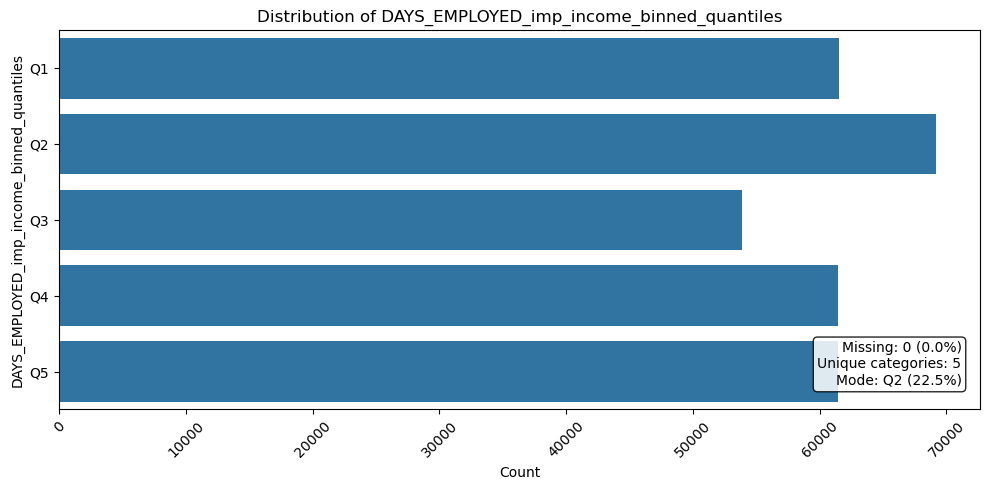

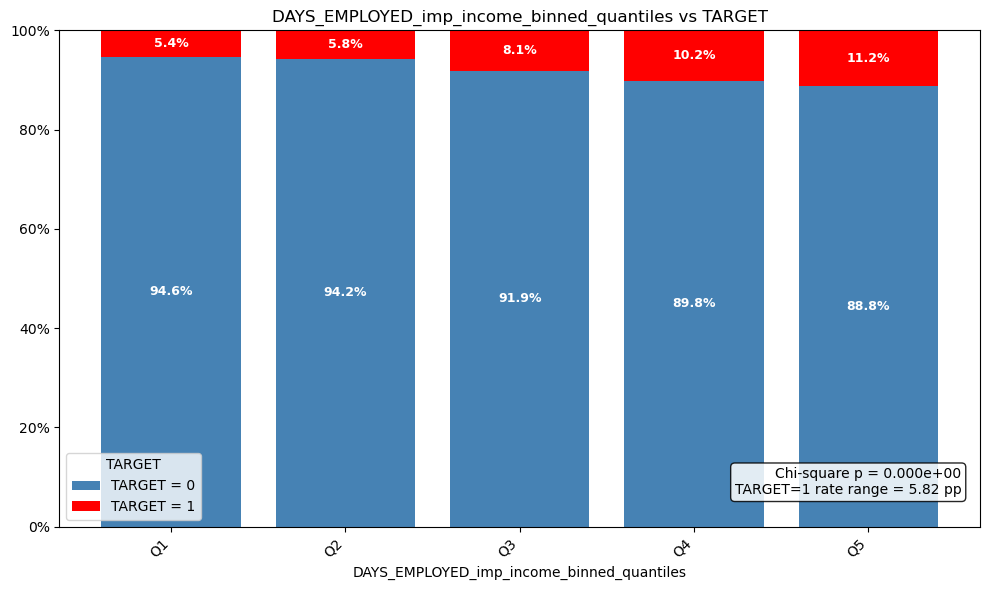

In [27]:
plot_categorical_distribution(df=binned_df, cat_var='DAYS_EMPLOYED_imp_income_binned_quantiles', respect_category_order=True)
plot_categorical_vs_binary(df=binned_df, cat_var='DAYS_EMPLOYED_imp_income_binned_quantiles', target_var='TARGET', respect_category_order=True)

## 4. DAYS_REGISTRATION
How many days before the application did client change his registration, time only relative to the application

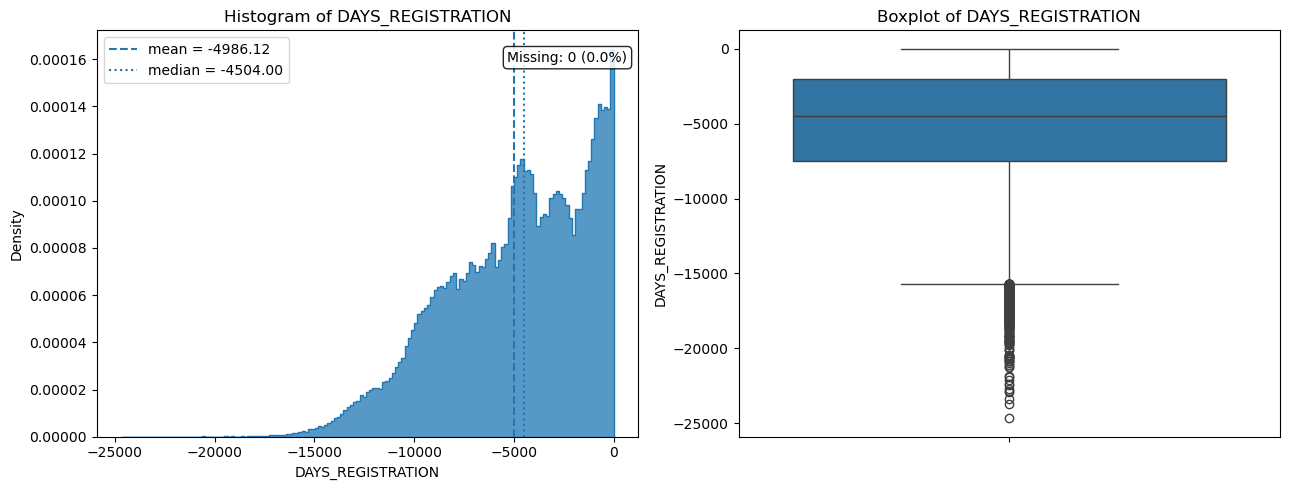

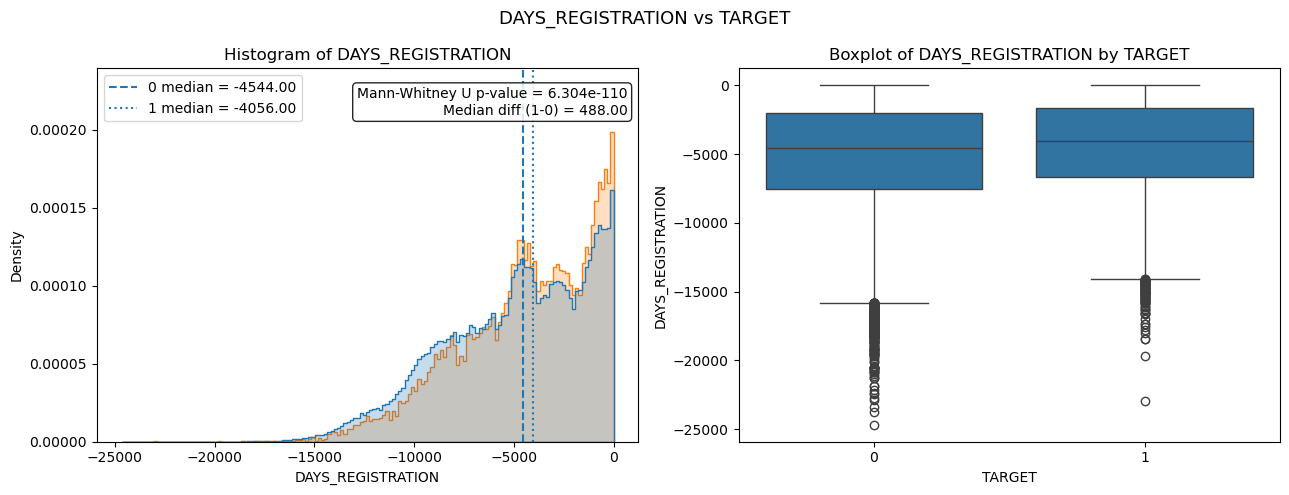

In [28]:
plot_quantitative_distribution(df=df_imp, quant_var='DAYS_REGISTRATION')
plot_quantitative_vs_binary(df=df_imp, quant_var='DAYS_REGISTRATION', target_var='TARGET')

In [29]:
binned_df, days_registration_summary = bin_quantitative_var(
    df = app_df,
    quant_var='DAYS_REGISTRATION',
    quantiles_bins=True,
    target_var='TARGET',
    return_binned_quantiles=False,
    return_summary=True,
    return_df=True
)

days_registration_summary

,feature,binned_column,binning_type,bin,count,share,n_target_1,n_target_0,target_rate
0,DAYS_REGISTRATION,DAYS_REGISTRATION_binned_quantiles,quantiles,Q1,61507,0.200016,3762,57745,0.061164
1,DAYS_REGISTRATION,DAYS_REGISTRATION_binned_quantiles,quantiles,Q2,61514,0.200038,4666,56848,0.075853
2,DAYS_REGISTRATION,DAYS_REGISTRATION_binned_quantiles,quantiles,Q3,61491,0.199964,5343,56148,0.086891
3,DAYS_REGISTRATION,DAYS_REGISTRATION_binned_quantiles,quantiles,Q4,61536,0.200110,5292,56244,0.085998
4,DAYS_REGISTRATION,DAYS_REGISTRATION_binned_quantiles,quantiles,Q5,61463,0.199873,5762,55701,0.093747


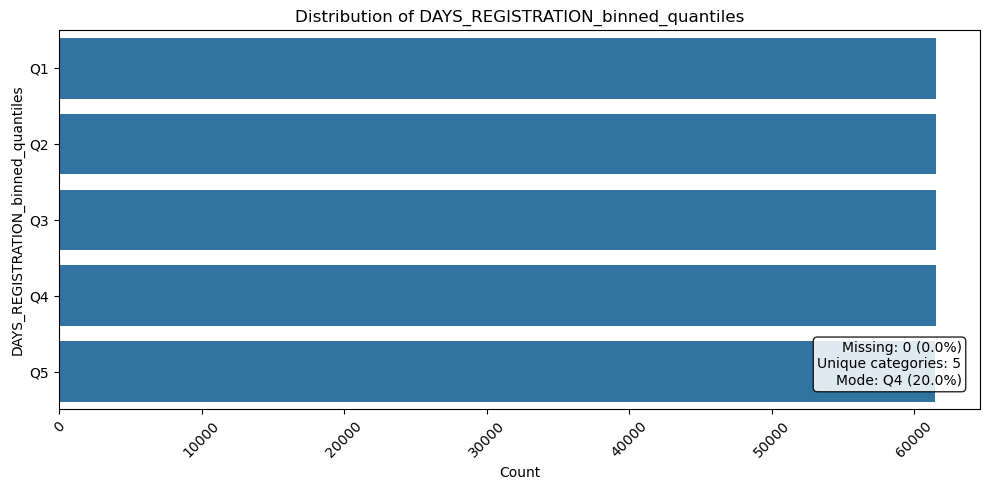

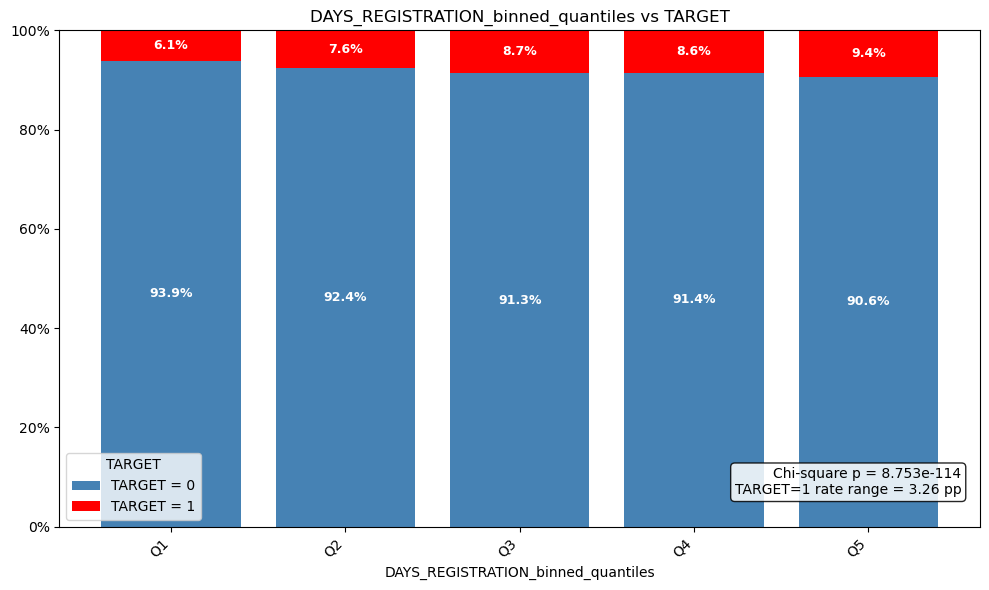

In [30]:
plot_categorical_distribution(df=binned_df, cat_var='DAYS_REGISTRATION_binned_quantiles', respect_category_order=True)
plot_categorical_vs_binary(df=binned_df, cat_var='DAYS_REGISTRATION_binned_quantiles', target_var='TARGET', respect_category_order=True)

Clients that defaulted have slightly less time between change in their registration and the application. This might be useful for the future model.

## 5. DAYS_LAST_PHONE_CHANGE
How many days before application did client change phone


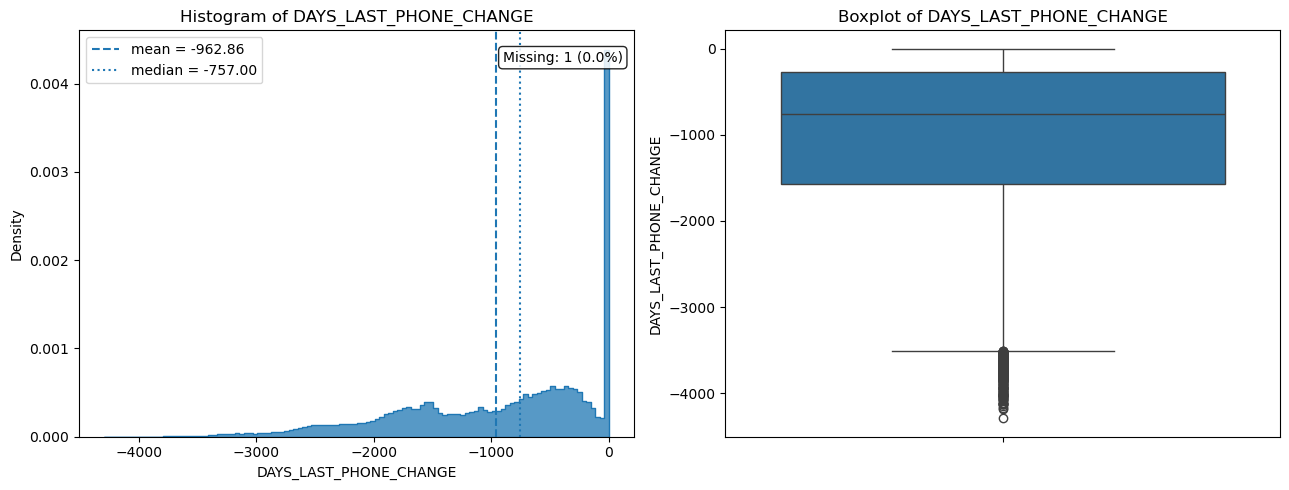

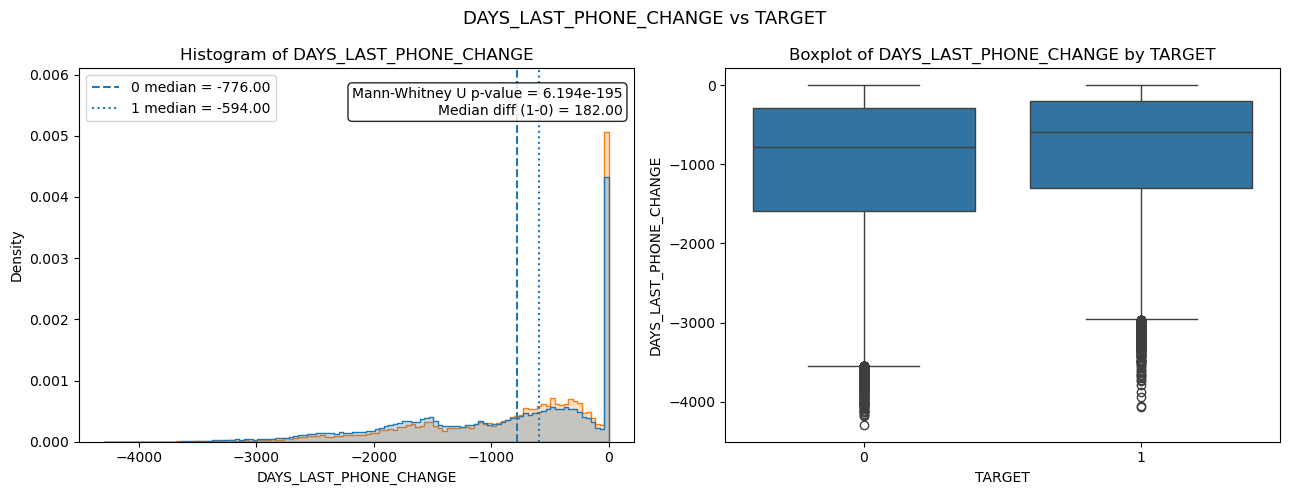

In [31]:
plot_quantitative_distribution(df=df_imp, quant_var='DAYS_LAST_PHONE_CHANGE')
plot_quantitative_vs_binary(df=df_imp, quant_var='DAYS_LAST_PHONE_CHANGE', target_var='TARGET')

In [32]:
binned_df, days_last_phone_change_summary = bin_quantitative_var(
    df = df_imp,
    quant_var='DAYS_LAST_PHONE_CHANGE',
    quantiles_bins=True,
    target_var='TARGET',
    return_binned_quantiles=False,
    return_summary=True,
    return_df=True
)

days_last_phone_change_summary

,feature,binned_column,binning_type,bin,count,share,n_target_1,n_target_0,target_rate
0,DAYS_LAST_PHONE_CHANGE,DAYS_LAST_PHONE_CHANGE_binned_quantiles,quantiles,Q1,61551,0.200159,3533,58018,0.057400
1,DAYS_LAST_PHONE_CHANGE,DAYS_LAST_PHONE_CHANGE_binned_quantiles,quantiles,Q2,61469,0.199892,4213,57256,0.068539
2,DAYS_LAST_PHONE_CHANGE,DAYS_LAST_PHONE_CHANGE_binned_quantiles,quantiles,Q3,61659,0.200510,5427,56232,0.088016
3,DAYS_LAST_PHONE_CHANGE,DAYS_LAST_PHONE_CHANGE_binned_quantiles,quantiles,Q4,61407,0.199690,5864,55543,0.095494
4,DAYS_LAST_PHONE_CHANGE,DAYS_LAST_PHONE_CHANGE_binned_quantiles,quantiles,Q5,61424,0.199746,5788,55636,0.094230
5,DAYS_LAST_PHONE_CHANGE,DAYS_LAST_PHONE_CHANGE_binned_quantiles,quantiles,NaN,1,0.000003,0,1,0.000000


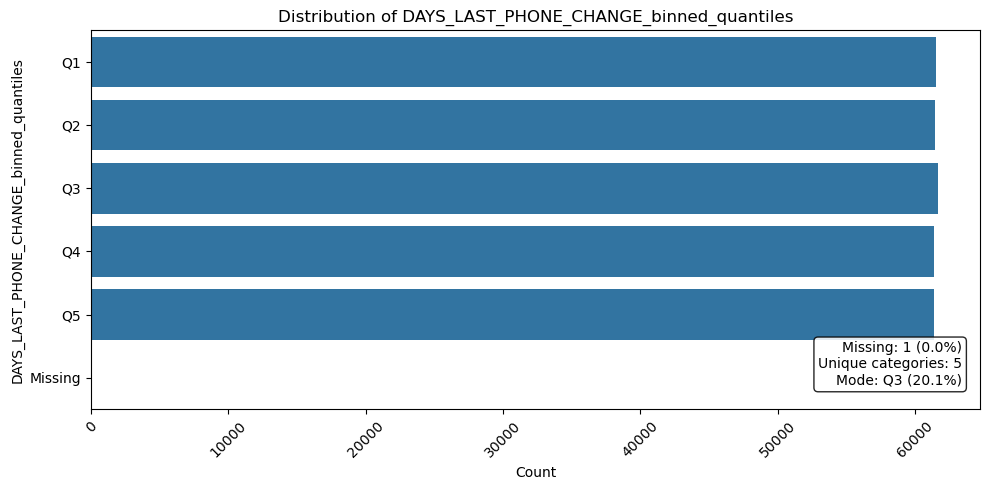

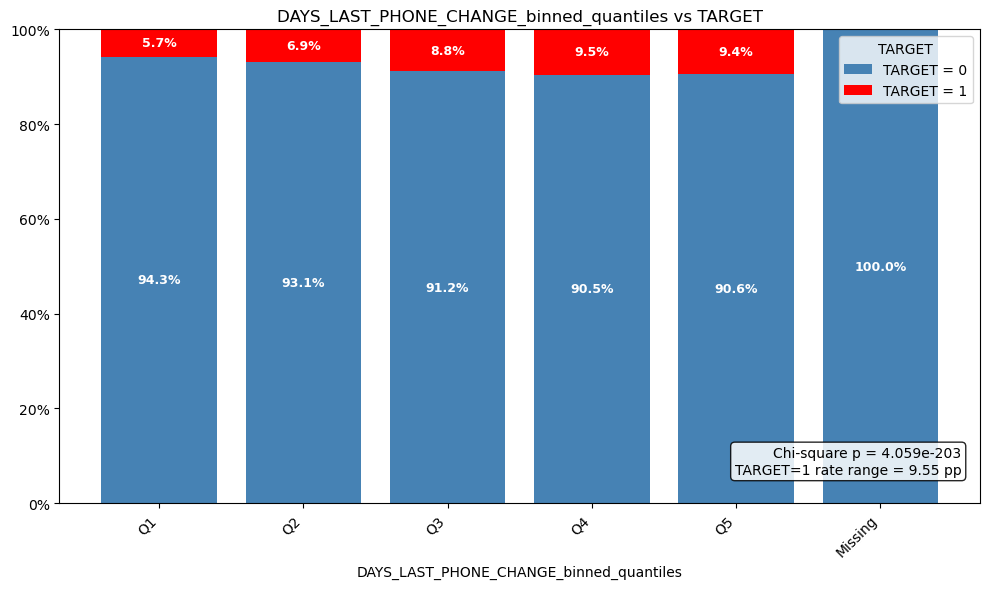

In [33]:
days_employed_summary
plot_categorical_distribution(df=binned_df, cat_var='DAYS_LAST_PHONE_CHANGE_binned_quantiles', respect_category_order=True)
plot_categorical_vs_binary(df=binned_df, cat_var='DAYS_LAST_PHONE_CHANGE_binned_quantiles', target_var='TARGET', respect_category_order=True)

Statistically significant difference in distributions can be observed. The variable has 1 missing value which cen be dismissed.

## 6. WEEKDAY_APPR_PROCESS_START
On which day of the week did the client apply for the loan

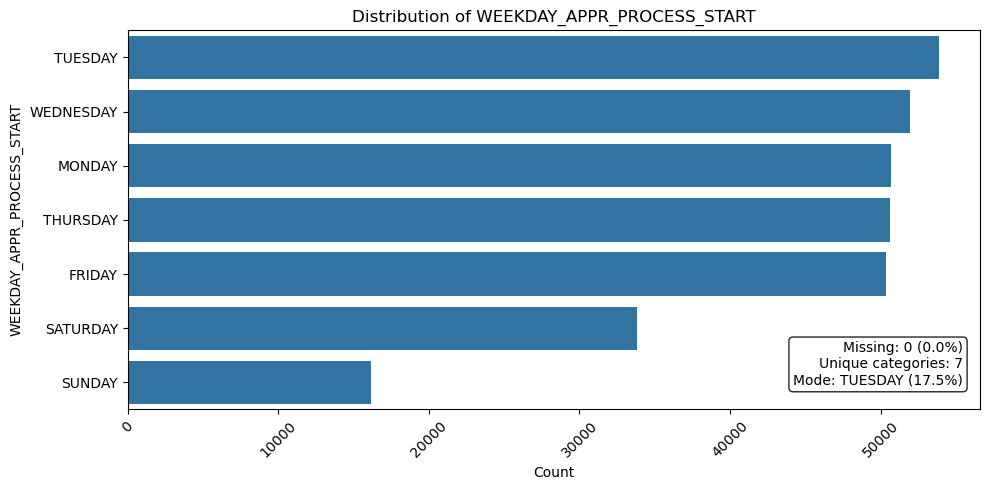

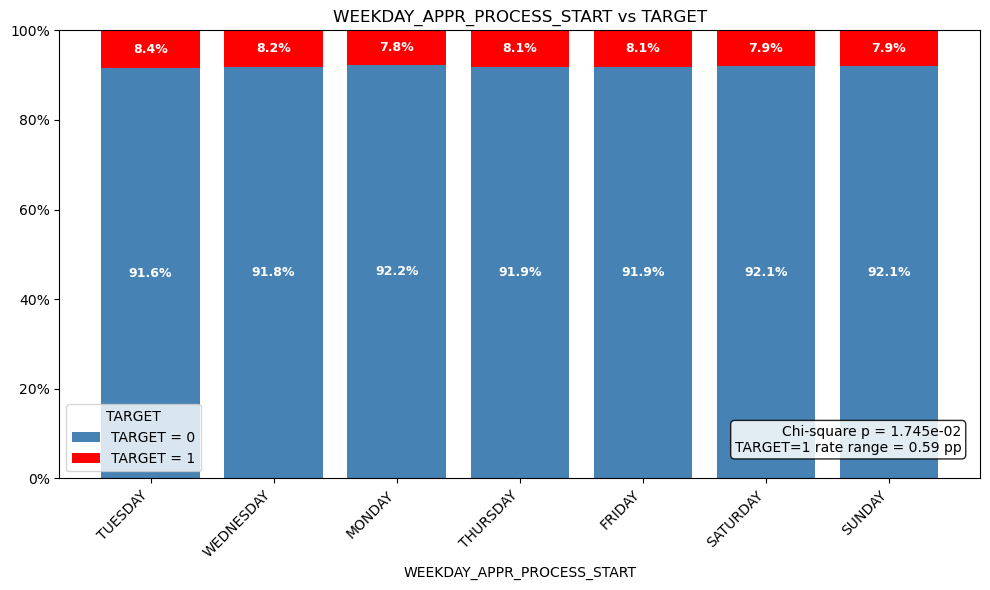

In [34]:
plot_categorical_distribution(df=df_imp, cat_var='WEEKDAY_APPR_PROCESS_START')
plot_categorical_vs_binary(df=df_imp, cat_var='WEEKDAY_APPR_PROCESS_START', target_var='TARGET')

The p-value is 0.01745 which suggest that the statisticall sigificane depends on the confidence level.  <br>
The plot shows taht differences are not big and they are probably random, there is no logic and theory behind applying at different weakdays and defaulting.

## 7. HOUR_APPR_PROCESS_START
Approximately at what hour did the client apply for the loan, rounded

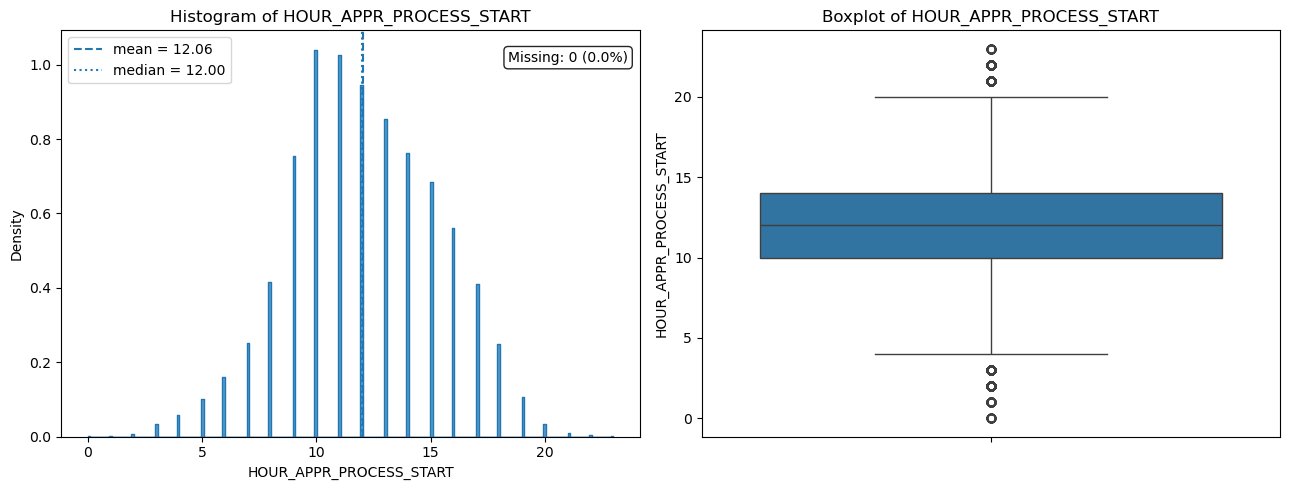

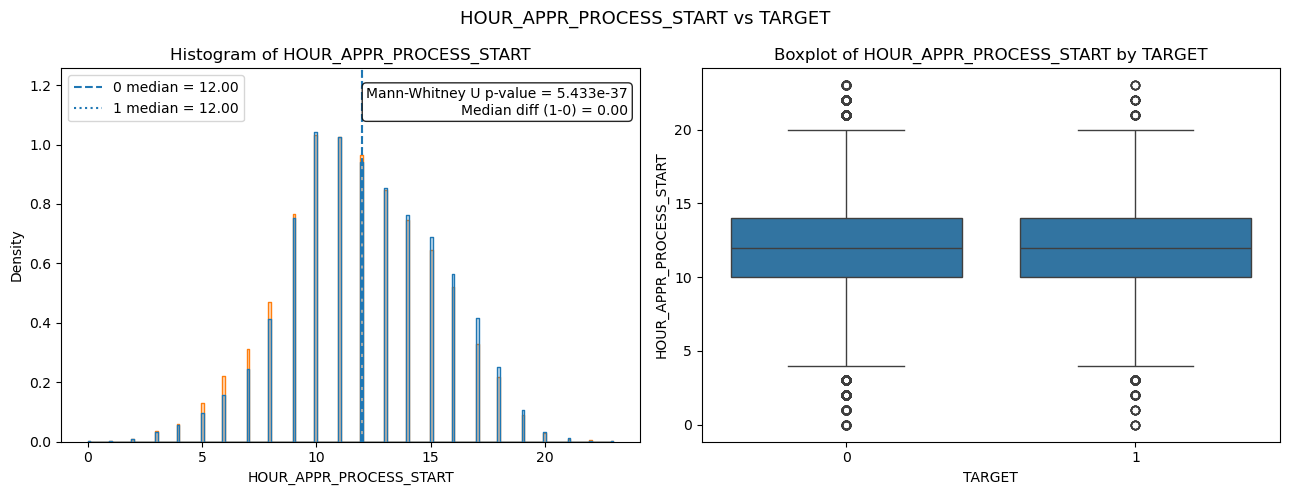

In [35]:
plot_quantitative_distribution(df=df_imp, quant_var='HOUR_APPR_PROCESS_START')
plot_quantitative_vs_binary(df=df_imp, quant_var='HOUR_APPR_PROCESS_START', target_var='TARGET')

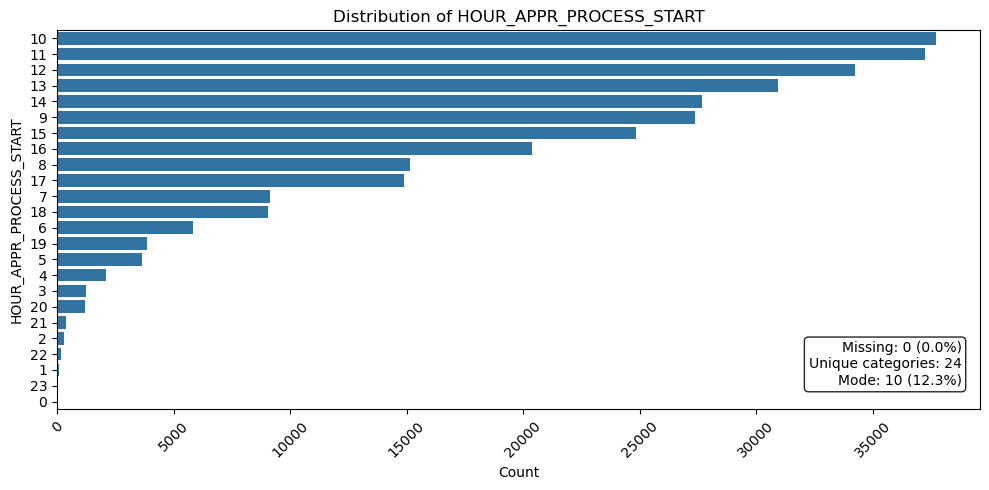

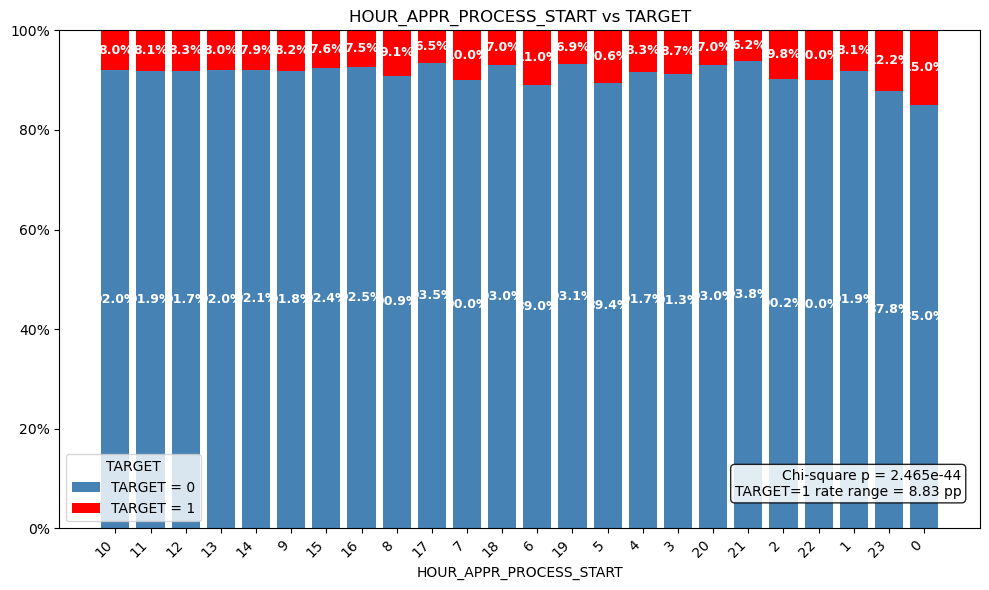

In [36]:
plot_categorical_distribution(
    df=df_imp.assign(HOUR_APPR_PROCESS_START=df_imp["HOUR_APPR_PROCESS_START"].astype(int).astype(str)),
    cat_var="HOUR_APPR_PROCESS_START",
)
plot_categorical_vs_binary(
    df=df_imp.assign(HOUR_APPR_PROCESS_START=df_imp["HOUR_APPR_PROCESS_START"].astype(int).astype(str)),
    cat_var="HOUR_APPR_PROCESS_START",
    target_var='TARGET'
)

Surprisingly there are some statistically significant differences so this variable will be used in further analysis.

## 8. FLAG_MOBIL
Did client provide mobile phone (1=YES, 0=NO)

In [37]:
df_imp['FLAG_MOBIL'].value_counts()

FLAG_MOBIL
1    307510
0         1
Name: count, dtype: int64

In [38]:
df_imp.loc[df_imp['FLAG_MOBIL']==0]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,NAME_TYPE_SUITE_grouped,DAYS_EMPLOYED_invalid,DAYS_EMPLOYED_imp_global,DAYS_EMPLOYED_imp_income,DAYS_EMPLOYED_imp_income_gender,DAYS_EMPLOYED_imp_occupation,DAYS_EMPLOYED_imp_occupation_gender
15709,118330,0,Cash loans,M,Y,Y,0,126000.0,278613.0,25911.0,...,NaN,NaN,NaN,Unaccompanied,0,-293.0,-293.0,-293.0,-293.0,-293.0


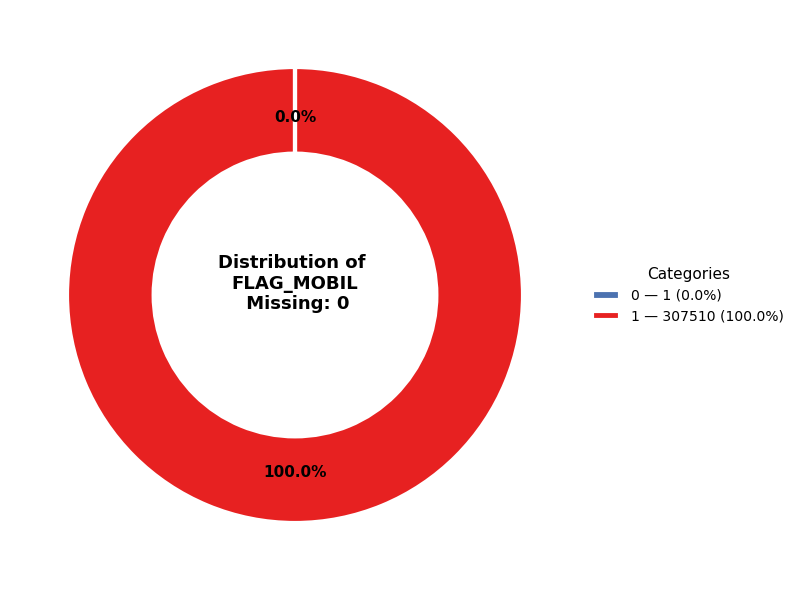

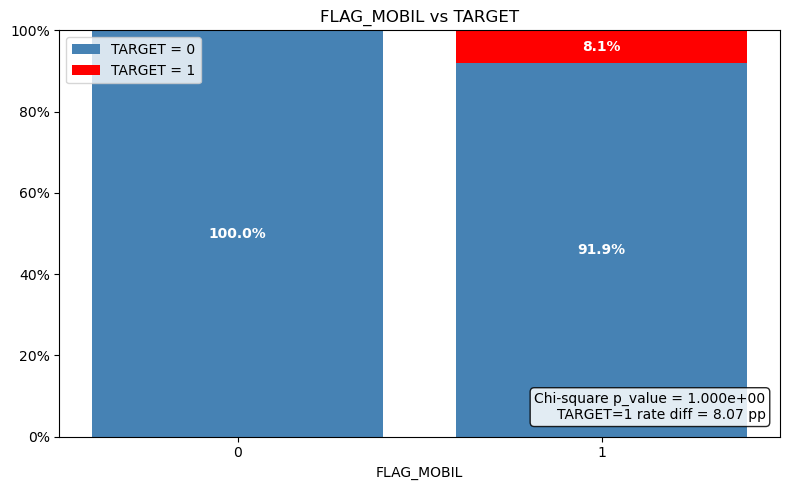

In [39]:
plot_binary_distribution(df=df_imp, binary_var='FLAG_MOBIL')
plot_binary_vs_binary(df=df_imp, binary_var='FLAG_MOBIL', target_var='TARGET')

The `FLAG_MOBIL` varabile has only one observation with 0 value, so it bears no information for the model.
We will not use it.

## 9. FLAG_EMP_PHONE
Did client provide work phone (1=YES, 0=NO)

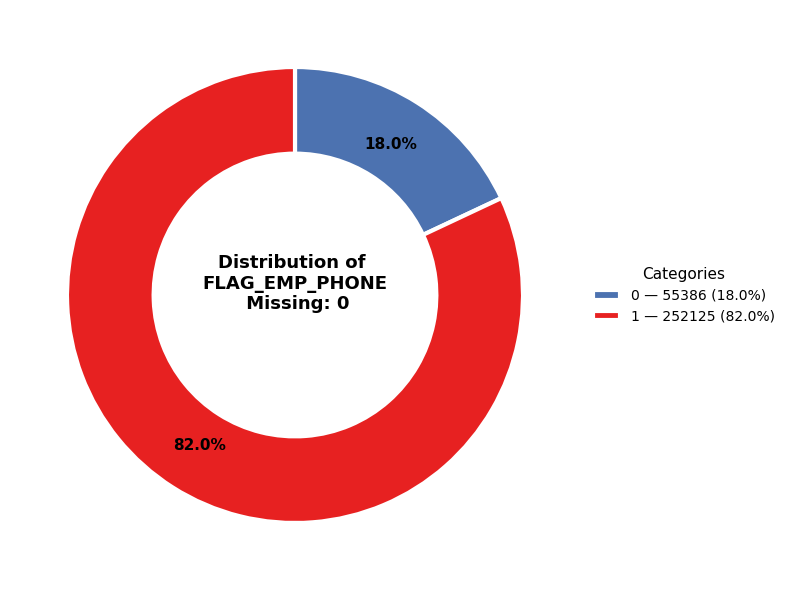

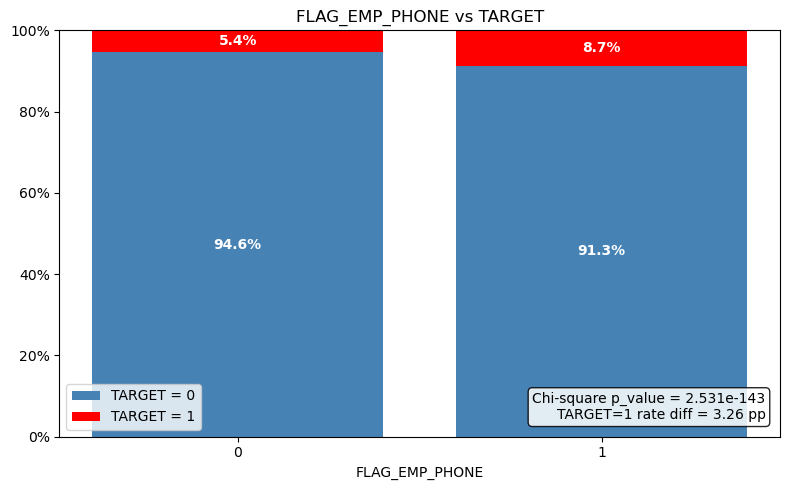

In [40]:
plot_binary_distribution(df=df_imp, binary_var='FLAG_EMP_PHONE')
plot_binary_vs_binary(df=df_imp, binary_var='FLAG_EMP_PHONE', target_var='TARGET')

There is a small difference in distributions, the variable can be used by the model but for sure it won't be crucial

## 10. FLAG_WORK_PHONE
Did client provide home phone (1=YES, 0=NO)

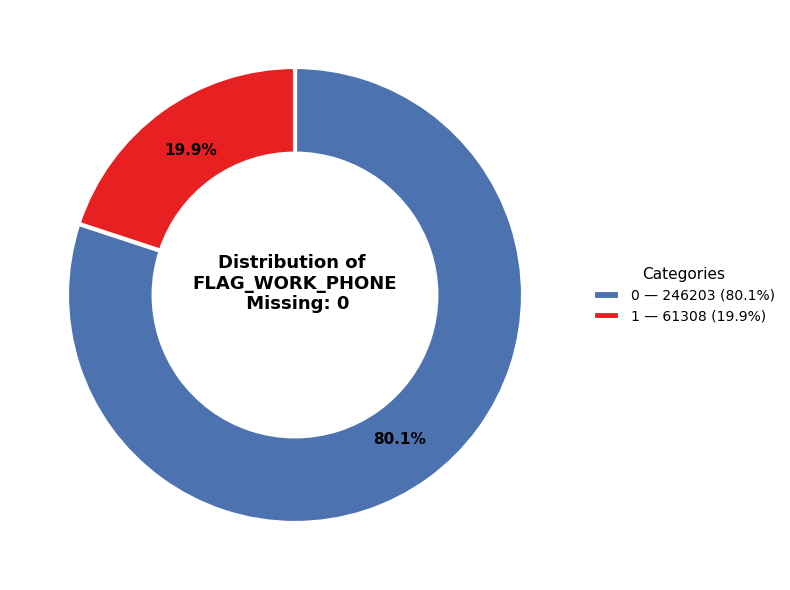

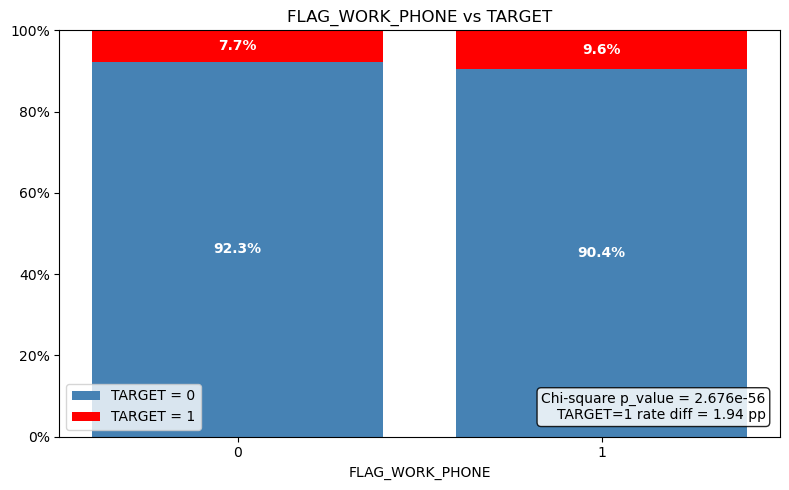

In [41]:
plot_binary_distribution(df=df_imp, binary_var='FLAG_WORK_PHONE')
plot_binary_vs_binary(df=df_imp, binary_var='FLAG_WORK_PHONE', target_var='TARGET')

The difference in distributions is statistically significant but the in terms of absolute values it is not substantial. We will see if models can learn patterns form this variable.

## 11. FLAG_CONT_MOBILE 
Was mobile phone reachable (1=YES, 0=NO)

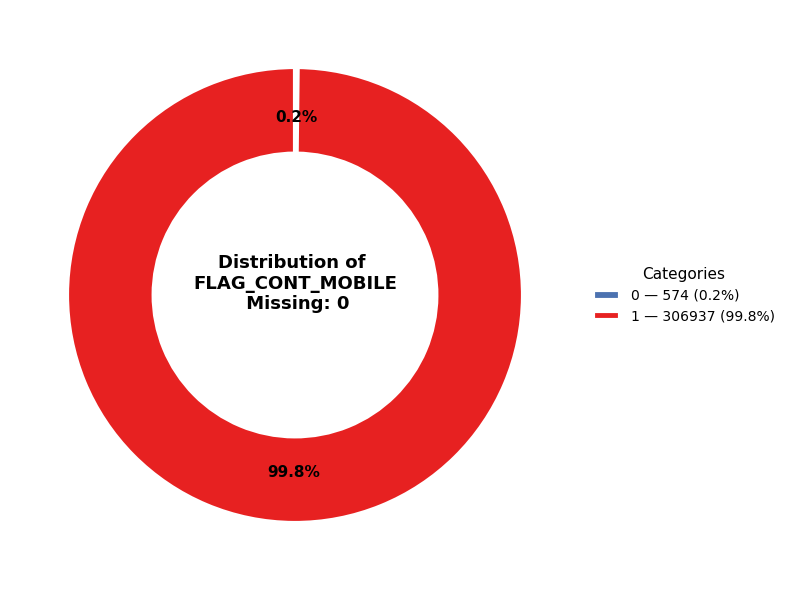

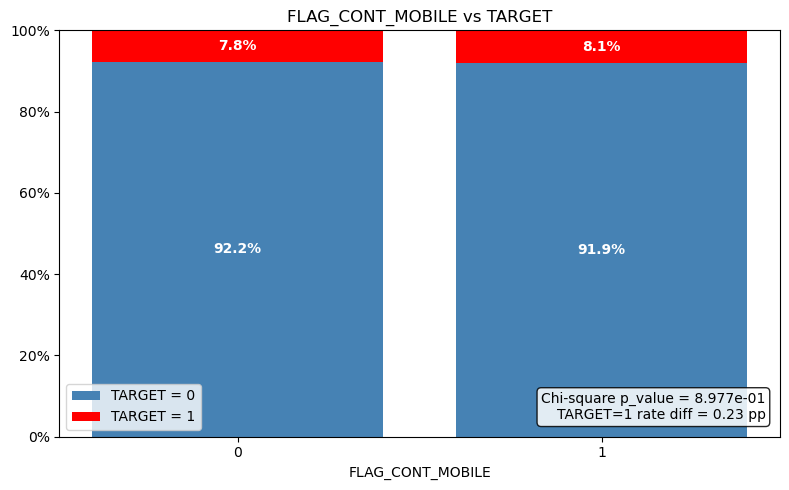

In [42]:
plot_binary_distribution(df=df_imp, binary_var='FLAG_CONT_MOBILE')
plot_binary_vs_binary(df=df_imp, binary_var='FLAG_CONT_MOBILE', target_var='TARGET')

The difference is not statistically significant and the variable is dominated by one value. It shouldn't be used in modeling.

## 12. FLAG_PHONE
Did client provide home phone (1=YES, 0=NO)

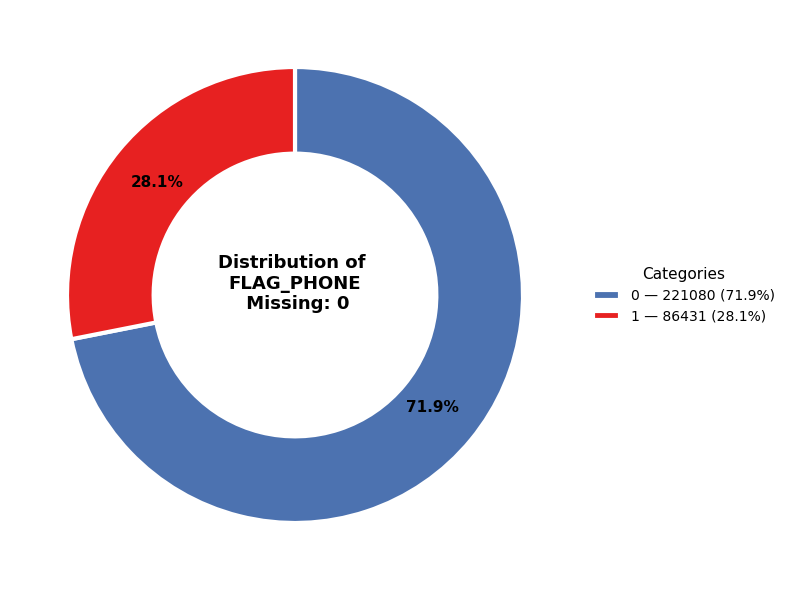

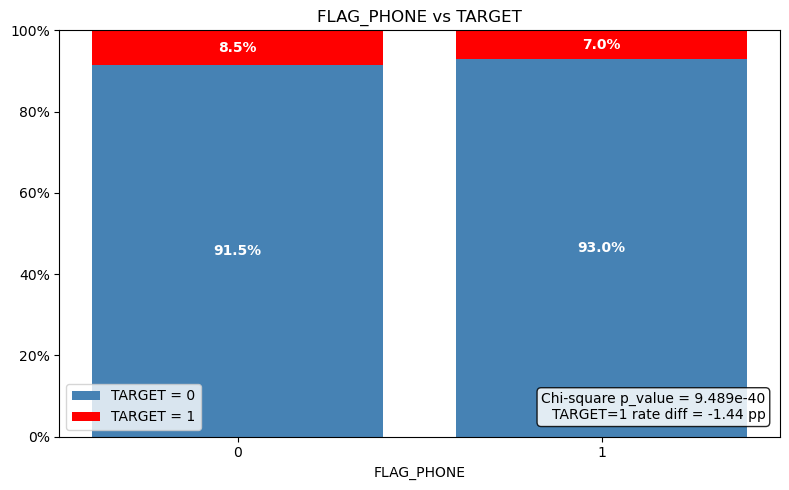

In [43]:
plot_binary_distribution(df=df_imp, binary_var='FLAG_PHONE')
plot_binary_vs_binary(df=df_imp, binary_var='FLAG_PHONE', target_var='TARGET')

The difference is statistically significant so it will be used in modeling.

## 13. FLAG_EMAIL
Did client provide email (1=YES, 0=NO)
 

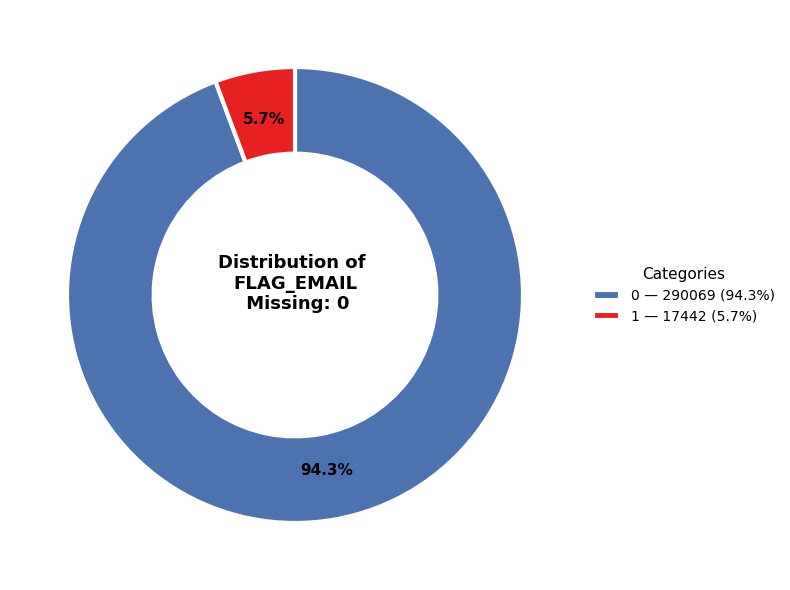

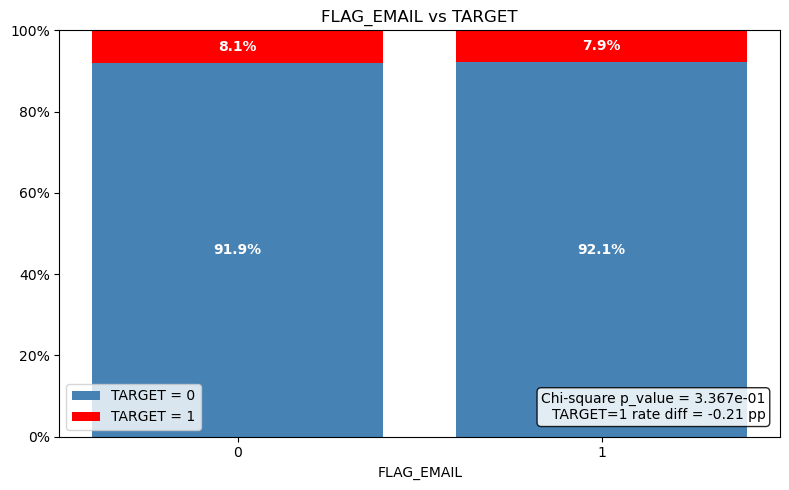

In [44]:
plot_binary_distribution(df=df_imp, binary_var='FLAG_EMAIL')
plot_binary_vs_binary(df=df_imp, binary_var='FLAG_EMAIL', target_var='TARGET')

The difference is not statistically significant. It won't be used in the modeling

## 8. Application process summary
Variables that should be used as predictors
- `NAME_TYPE_SUITE_MISSING`
- `DAYS_ID_PUBLISH`
- `DAYS_ID_PUBLISH_binned_quantiles`
- `DAYS_EMPLOYED`
- `DAYS_EMPLOYED_invalid`
- `DAYS_EMPLOYED_imp_income`
- `DAYS_EMPLOYED_imp_income_binned_quantiles`
- `DAYS_REGISTRATION`
- `DAYS_REGISTRATION_binned_quantiles`
- `DAYS_LAST_PHONE_CHANGE`
- `DAYS_LAST_PHONE_CHANGE_binned_quantiles`
- `FLAG_EMP_PHONE`
- `FLAG_WORK_PHONE`
- `FLAG_PHONE`